## Cell 1:

In [43]:
import pandas as pd
from pathlib import Path

# In Colab, upload Divar.csv to /content or set CSV_PATH to its Drive path.
CSV_PATH = next((p for p in [Path("../data/Divar.csv"), Path("Divar.csv"),
                           Path("/content/Divar.csv")]
                 if p.is_file()), Path("../data/Divar.csv"))
required_columns = ["cat3_slug", "city_slug", "location_latitude",
                    "location_longitude", "price_value"]
data = pd.read_csv(CSV_PATH, usecols=required_columns)

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score
from kneed import KneeLocator
from pyproj import Transformer

plt.rcParams.update({"figure.figsize": (8, 5), "font.size": 11})
display(data.head())

,cat3_slug,city_slug,price_value,location_latitude,location_longitude
0,villa,karaj,NaN,35.811684,50.936600
1,apartment-sell,tehran,8.500000e+09,NaN,NaN
2,apartment-rent,tehran,NaN,35.703865,51.373459
3,office-rent,tehran,NaN,NaN,NaN
4,apartment-sell,mashhad,5.750000e+09,NaN,NaN


## Cell 2:

In [45]:
columns = ["location_latitude", "location_longitude", "price_value"]

# انتخاب فروش آپارتمان در تمام شهرها و نگه‌داشتن سه ستون
df = data.loc[
    ((data["cat3_slug"] == "apartment-sell") | (data["cat3_slug"] == "villa")), #&
    # (data["city_slug"] == "tehran"),
    columns
].copy()

initial_count = len(df)
print(f"Initially selected rows: {initial_count:,}")
print("Missing values before numeric conversion:")
display(df.isna().sum())

# تبدیل مقادیر غیرعددی و نامتناهی به مقدار گمشده
for col in columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

# حذف ردیف‌هایی که حداقل یکی از سه ویژگی آن‌ها گمشده است
before_null_drop = len(df)
df = df.dropna(subset=columns).copy()
after_null_drop = len(df)
null_removed = before_null_drop - after_null_drop

# حذف قیمت‌های خارج از محدوده؛ هر دو حد مجاز هستند
before_price_filter = len(df)
valid_price = df["price_value"].between(
    1_000_000,
    1_000_000_000_000,
    inclusive="both"
)
df = df.loc[valid_price].copy()
after_price_filter = len(df)
price_removed = before_price_filter - after_price_filter

# گزارش تعداد و درصد حذف در هر مرحله
report = pd.DataFrame([
    {
        "stage": "Drop missing / nonnumeric / infinite values",
        "input_rows": before_null_drop,
        "removed_rows": null_removed,
        "removed_pct": (
            100 * null_removed / before_null_drop
            if before_null_drop else 0.0
        ),
        "remaining_rows": after_null_drop
    },
    {
        "stage": "Remove prices outside the allowed range",
        "input_rows": before_price_filter,
        "removed_rows": price_removed,
        "removed_pct": (
            100 * price_removed / before_price_filter
            if before_price_filter else 0.0
        ),
        "remaining_rows": after_price_filter
    }
])

display(report.round({"removed_pct": 2}))

total_removed = initial_count - len(df)
total_removed_pct = (
    100 * total_removed / initial_count if initial_count else 0.0
)

print(f"Final rows: {len(df):,}")
print(
    f"Total removed: {total_removed:,} "
    f"({total_removed_pct:.2f}% of initially selected rows)"
)

if len(df) < 30:
    raise ValueError(
        "Too few valid rows after cleaning; check the input data."
    )

display(df.describe())
df["price_value"] = np.log(df["price_value"])

Initially selected rows: 316,284
Missing values before numeric conversion:


location_latitude     102605
location_longitude    102605
price_value            12903
dtype: int64

,stage,input_rows,removed_rows,removed_pct,remaining_rows
0,Drop missing / nonnumeric / infinite values,316284,111214,35.16,205070
1,Remove prices outside the allowed range,205070,2389,1.16,202681


Final rows: 202,681
Total removed: 113,603 (35.92% of initially selected rows)


,location_latitude,location_longitude,price_value
count,202681.000000,202681.000000,2.026810e+05
mean,35.238111,51.590744,6.212374e+09
std,2.006523,2.868361,1.484156e+10
min,23.636976,43.774818,1.000000e+06
25%,35.535343,50.930592,1.950000e+09
50%,35.722778,51.327030,3.300000e+09
75%,35.840324,51.577244,6.300000e+09
max,40.358055,62.519234,1.000000e+12


## Cell 3:

In [46]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32639", always_xy=True)
df["utm_x"], df["utm_y"] = transformer.transform(
    df["location_longitude"].to_numpy(),
    df["location_latitude"].to_numpy()
)
features = ["utm_x", "utm_y", "price_value"]
raw = df[features].copy()
# raw = raw.sample(15_000)
display(raw.head())

,utm_x,utm_y,price_value
7,5.457116e+05,3.954101e+06,22.886589
8,4.814371e+05,3.952066e+06,20.292483
10,5.684670e+05,3.959664e+06,21.678777
12,1.266003e+06,4.053542e+06,23.287446
30,5.666540e+05,3.908094e+06,20.671973


## Cell 4:

IQR removed: 77,376 / 202,681 (38.18%)
Remaining rows: 125,305


,lower,upper
utm_x,3.160739e+05,7.305818e+05
utm_y,3.832097e+06,4.066857e+06
price_value,1.787293e+01,2.608198e+01


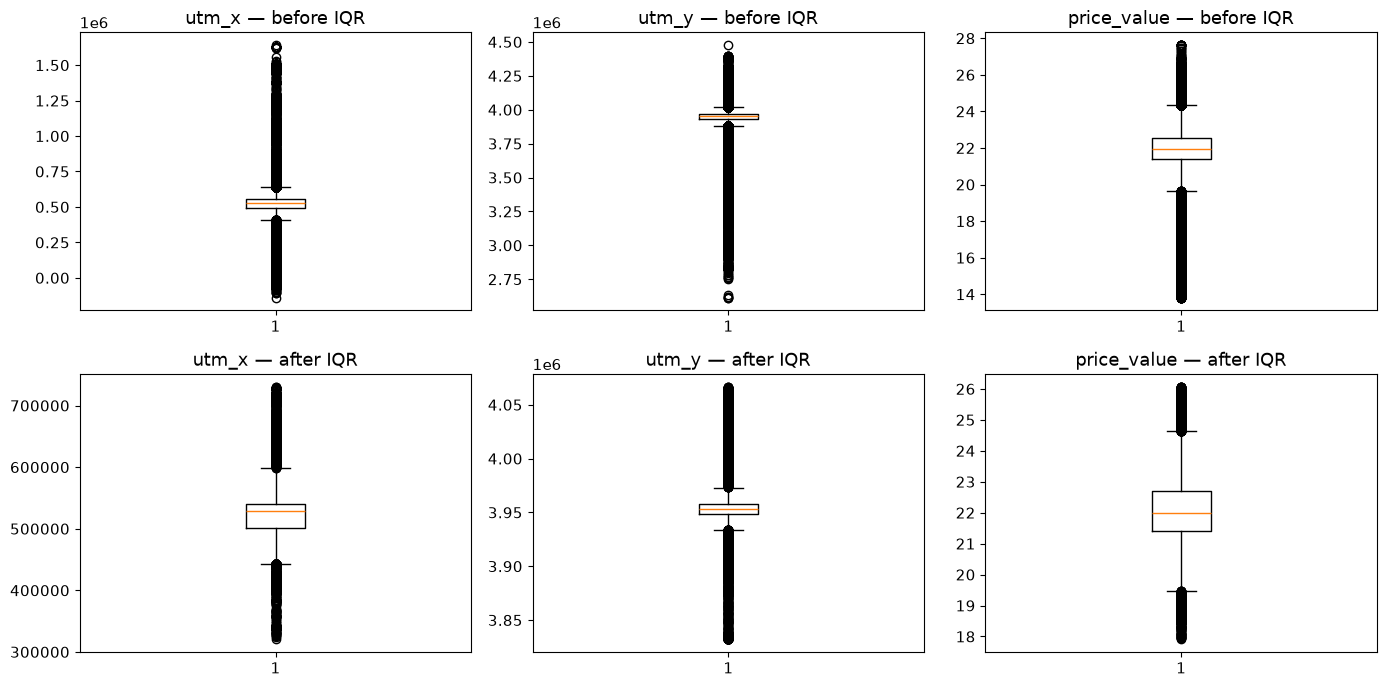

In [47]:
features = ["utm_x", "utm_y", "price_value"]

q1 = raw[features].quantile(0.25)
q3 = raw[features].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 3 * iqr, q3 + 3 * iqr

# حذف ردیف اگر حداقل یکی از سه ویژگی خارج از محدوده باشد
keep = (
    raw[features].ge(lower) & raw[features].le(upper)
).all(axis=1)

clean = raw.loc[keep].copy()

removed = (~keep).sum()
removed_pct = 100 * removed / len(raw) if len(raw) else 0.0
print(f"IQR removed: {removed:,} / {len(raw):,} ({removed_pct:.2f}%)")
print(f"Remaining rows: {len(clean):,}")

display(pd.DataFrame({"lower": lower, "upper": upper}))

if len(clean) < 30 or (clean[features].std() == 0).any():
    raise ValueError("Insufficient data or a constant feature after cleaning.")

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for j, col in enumerate(features):
    axes[0, j].boxplot(raw[col].to_numpy())
    axes[0, j].set_title(f"{col} — before IQR")

    axes[1, j].boxplot(clean[col].to_numpy())
    axes[1, j].set_title(f"{col} — after IQR")

plt.tight_layout()
plt.show()

## Cell 5:

,utm_x_scaled,utm_y_scaled,transformed_price_value
213048,0.175067,-0.173523,0.240952
669926,-0.754752,0.475255,0.656350
443342,0.378678,0.173721,2.152283
338474,-0.376905,-0.109942,-0.469174
873137,0.083450,-0.437360,-0.766639


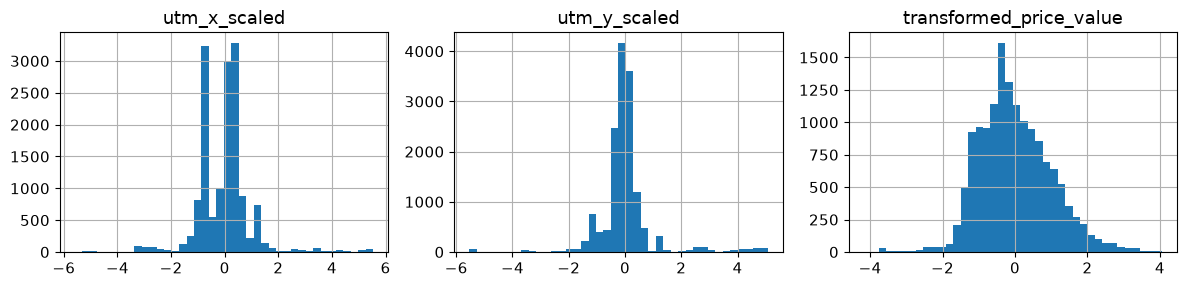

In [48]:
scaler = StandardScaler()
clean = clean.sample(15_000)
model_data = pd.DataFrame(
    scaler.fit_transform(clean[features]),
    columns=["utm_x_scaled", "utm_y_scaled", "transformed_price_value"],
    index=clean.index
)

X = model_data.to_numpy()
display(model_data.head())
model_data.hist(bins=40, figsize=(12, 3), layout=(1, 3))
plt.tight_layout()
plt.show()

## Cell 6:

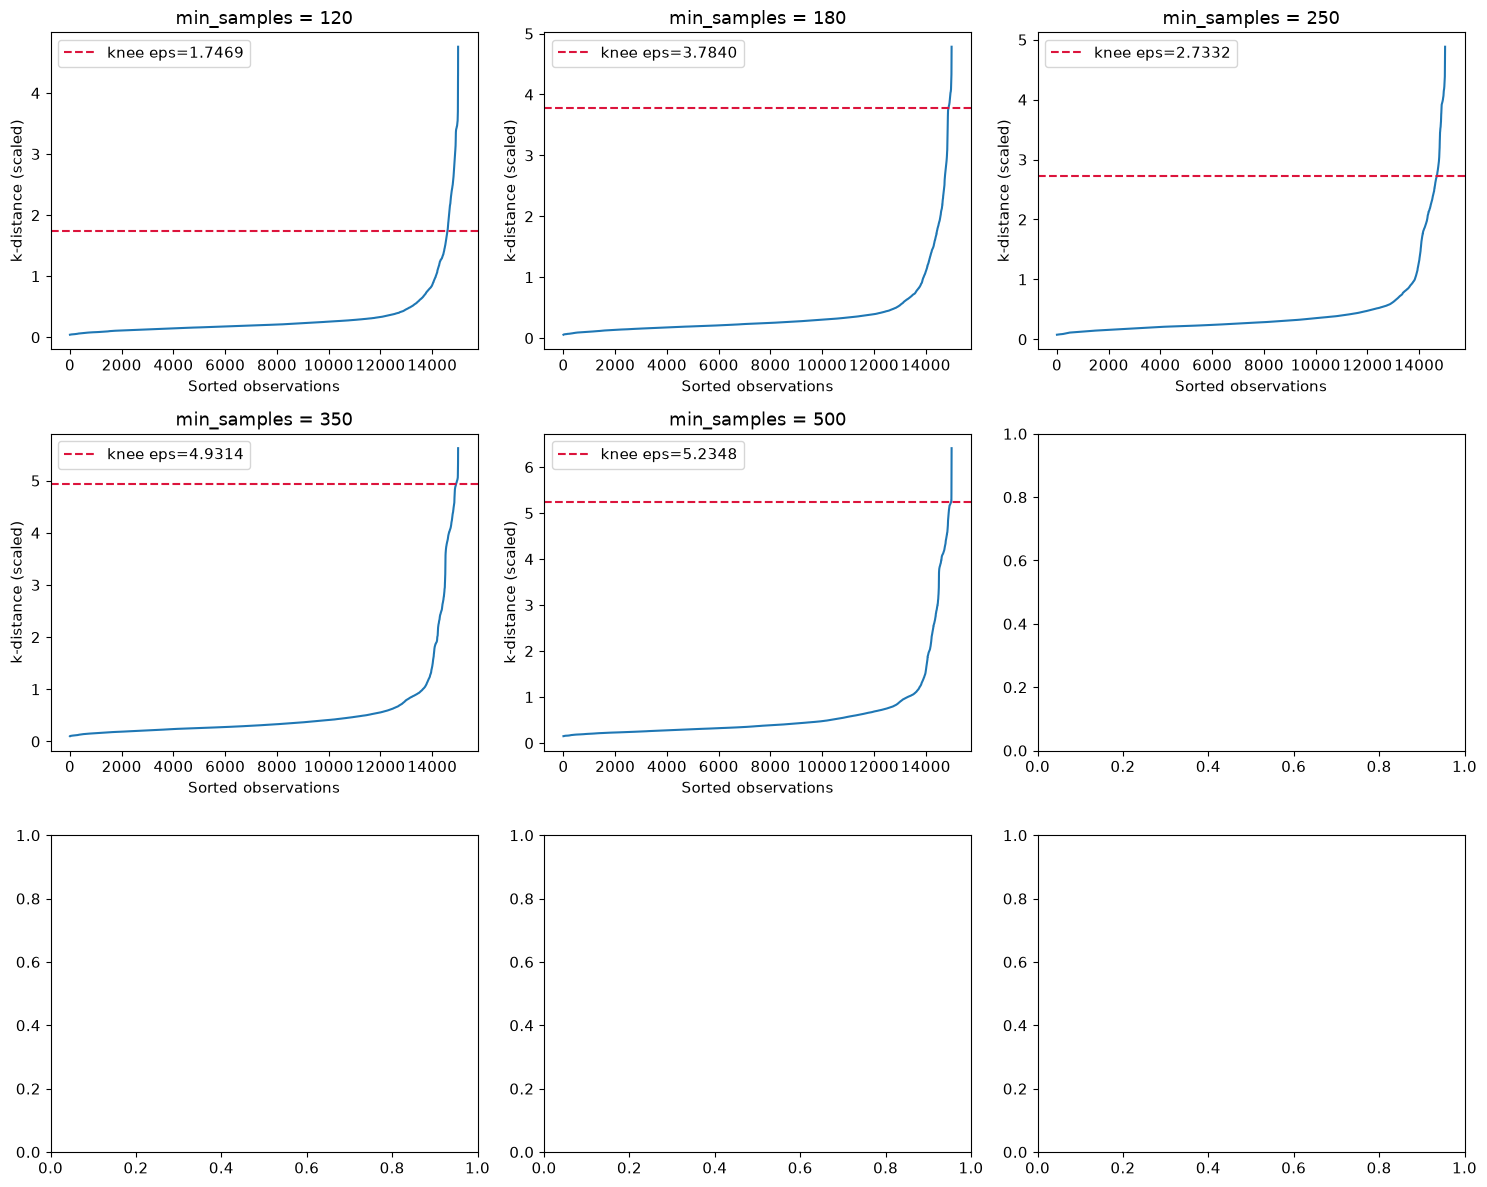

In [49]:
# min_samples_list = [10, 30, 60, 120, 180, 250, 350, 500, 750]
min_samples_list = [120, 180, 250, 350, 500]
min_samples_list = [m for m in min_samples_list if m <= len(X)]
knee_eps, distance_curves = {}, {}
nn = NearestNeighbors(n_neighbors=max(min_samples_list), algorithm="kd_tree", n_jobs=-1).fit(X)
neigh_dist = nn.kneighbors(X, return_distance=True)[0]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for m, ax in zip(min_samples_list, axes.flat):
    sorted_dist = np.sort(neigh_dist[:, m - 1])
    loc = KneeLocator(np.arange(len(X)), sorted_dist,
                      curve="convex", direction="increasing")
    eps = sorted_dist[int(loc.elbow)] if loc.elbow is not None else 0.0
    if eps <= 0:
        positive = sorted_dist[sorted_dist > 0]
        eps = float(np.quantile(positive, 0.90)) if len(positive) else 0.0
        print(f"min_samples={m}: no positive knee; using the positive 90th percentile.")
    knee_eps[m] = float(eps)
    distance_curves[m] = sorted_dist
    ax.plot(sorted_dist)
    ax.axhline(eps, color="crimson", ls="--", label=f"knee eps={eps:.4f}")
    ax.set(title=f"min_samples = {m}", xlabel="Sorted observations",
           ylabel="k-distance (scaled)")
    ax.legend()
del neigh_dist, nn
plt.tight_layout()
plt.show()

## Cell 7:

In [50]:
# from sklearn.metrics import silhouette_samples
# from scipy.optimize import linear_sum_assignment
# from sklearn.neighbors import KDTree
# import hashlib

# # True: محاسبه Silhouette برای تمام مدل‌های دارای حداقل دو خوشه
# # False: محاسبه فقط برای مدل‌های سه‌کلاستری، مانند نسخه قبلی
# COMPUTE_ALL_SILHOUETTES = False


# # تنظیمات جست‌وجو
# min_samples_list = [500, 900, 1400 , 1800 , 2200 , 2700]

# LOCAL_CHANGE = 0.20
# EXPANSION_CHANGE = 0.30
# MIN_SAMPLES_MIN = 1

# KNEE_MULTIPLIERS = np.round(np.linspace(0.3, 1.2, 4) , 4)
# EXPANSION_QUANTILES = [0.35, 0.70, 0.95]
# EXPANSION_SCALES = [1.0]
# MAX_EXPANSION_ROUNDS = 20

# # محدودیت EPS_MAX فقط برای جست‌وجوی اولیه و محلیِ آن است.
# EPS_MAX = 1.45

# MAX_NOISE = 0.40
# MIN_CLUSTER_SHARE = 0.01
# MAX_LARGEST_ASSIGNED_SHARE = 0.95

# PROBE_SIZE = 1500
# NEIGHBOR_BATCH_BYTES = 512 * 1024**2
# DBSCAN_MEMORY_BUDGET = 12 * 1024**3

# records, label_cache, tested, skipped = [], {}, set(), set()
# knee_eps, distance_curves, radius_budget_cache = {}, {}, {}

# search_fingerprint = None
# search_complete = False
# neighbor_model = radius_tree = None


# def reset_if_data_changed():
#     global search_fingerprint, search_complete, neighbor_model, radius_tree

#     signature = hashlib.sha256(
#         np.ascontiguousarray(X, dtype=np.float64).tobytes()
#     ).hexdigest()

#     if signature != search_fingerprint:
#         records.clear()
#         label_cache.clear()
#         tested.clear()
#         skipped.clear()
#         knee_eps.clear()
#         distance_curves.clear()
#         radius_budget_cache.clear()

#         search_complete = False
#         neighbor_model = radius_tree = None
#         search_fingerprint = signature

#         print(
#             f"Search data: shape={X.shape}, fingerprint={signature[:16]}",
#             flush=True
#         )

#     return signature


# def quality_mask(frame):
#     """پذیرش نامزد نیازمند برقراری هر چهار شرط است."""
#     return (
#         (frame.n_clusters == 3)
#         & (frame.noise_ratio <= MAX_NOISE)
#         & (frame.smallest_share >= MIN_CLUSTER_SHARE)
#         & (
#             frame.largest_assigned_share
#             <= MAX_LARGEST_ASSIGNED_SHARE
#         )
#     )


# def acceptable_candidates():
#     table = pd.DataFrame(records)
#     return table.loc[quality_mask(table)].copy() if len(table) else table


# def evaluate(labels, sample_size=2000, seeds=(42,), compute_score=True):
#     assigned = labels >= 0
#     ids, counts = np.unique(labels[assigned], return_counts=True)

#     shares = counts / counts.sum() if len(counts) else np.array([])
#     balance = (
#         -np.sum(shares * np.log(shares)) / np.log(len(ids))
#         if len(ids) > 1 else 0.0
#     )

#     scores, worst_scores = [], []

#     if compute_score and 2 <= len(ids) < assigned.sum():
#         all_idx = np.flatnonzero(assigned)

#         for seed in seeds:
#             rng = np.random.default_rng(seed)

#             if len(all_idx) <= sample_size:
#                 idx = all_idx
#             else:
#                 required = np.concatenate([
#                     rng.choice(
#                         np.flatnonzero(labels == k),
#                         min(2, count),
#                         replace=False
#                     )
#                     for k, count in zip(ids, counts)
#                 ])

#                 pool = np.setdiff1d(all_idx, required)
#                 extra = max(0, sample_size - len(required))

#                 idx = np.r_[
#                     required,
#                     rng.choice(pool, extra, replace=False)
#                 ]

#             values = silhouette_samples(X[idx], labels[idx])

#             per_cluster = np.array([
#                 values[labels[idx] == k].mean()
#                 for k in ids
#             ])

#             scores.append(float(per_cluster @ shares))
#             worst_scores.append(float(per_cluster.min()))

#     return {
#         "n_clusters": len(ids),
#         "noise_ratio": float((~assigned).mean()),
#         "smallest_share": (
#             float(counts.min() / len(X)) if len(counts) else 0.0
#         ),
#         "largest_assigned_share": (
#             float(shares.max()) if len(shares) else 0.0
#         ),
#         "balance": float(balance),
#         "silhouette": float(np.mean(scores)) if scores else np.nan,
#         "silhouette_std": float(np.std(scores)) if scores else np.nan,
#         "worst_cluster_silhouette": (
#             float(np.mean(worst_scores)) if worst_scores else np.nan
#         )
#     }


# def fit_labels(eps, m):
#     reset_if_data_changed()

#     key = (round(float(eps), 6), int(m))

#     if key not in label_cache:
#         model = DBSCAN(
#             eps=key[0],
#             min_samples=key[1],
#             algorithm="kd_tree",
#             n_jobs=-1
#         )
#         label_cache[key] = model.fit_predict(X).astype(np.int32)

#     return label_cache[key]


# def radius_is_safe(eps):
#     global radius_tree

#     if eps not in radius_budget_cache:
#         if radius_tree is None:
#             radius_tree = KDTree(X)

#         edge_count = radius_tree.query_radius(
#             X, r=eps, count_only=True
#         ).sum(dtype=np.int64)

#         radius_budget_cache[eps] = (
#             int(edge_count) * 24 <= DBSCAN_MEMORY_BUDGET
#         )

#     return radius_budget_cache[eps]

# def run_trial(eps, m, stage, eps_limit=np.inf):
#     reset_if_data_changed()
#     key = (round(float(eps), 6), int(m))

#     def report_skip(reason):
#         print(
#             f"[SKIP] stage={stage}, min_samples={key[1]}, "
#             f"eps={key[0]:.6f} | {reason}",
#             flush=True
#         )

#     if key in tested:
#         report_skip(
#             "این ترکیب قبلاً اجرا شده؛ اجرای تکراری حذف شد."
#         )
#         return

#     if key in skipped:
#         report_skip(
#             "این ترکیب قبلاً به دلیل عبور از بودجه حافظه رد شده است."
#         )
#         return

#     if not np.isfinite(key[0]):
#         report_skip(
#             "eps نامعتبر است: مقدار NaN یا بی‌نهایت."
#         )
#         return

#     if key[0] <= 0:
#         report_skip("eps باید بزرگ‌تر از صفر باشد.")
#         return

#     if key[0] > eps_limit:
#         report_skip(
#             f"eps={key[0]:.6f} از سقف مجاز "
#             f"eps_limit={eps_limit:.6f} در این مرحله بیشتر است."
#         )
#         return

#     if not MIN_SAMPLES_MIN <= key[1] <= len(X):
#         report_skip(
#             "min_samples خارج از بازه مجاز "
#             f"[{MIN_SAMPLES_MIN}, {len(X)}] است."
#         )
#         return

#     if not radius_is_safe(key[0]):
#         skipped.add(key)
#         report_skip(
#             "برآورد حافظه همسایگی‌ها از بودجه "
#             f"DBSCAN_MEMORY_BUDGET="
#             f"{DBSCAN_MEMORY_BUDGET / 1024**3:.2f} GiB "
#             "بیشتر است."
#         )
#         return

#     trial = fit_labels(*key)
#     stats = evaluate(trial, compute_score=False)

#     if (
#         stats["n_clusters"] == 3
#         or (
#             COMPUTE_ALL_SILHOUETTES
#             and stats["n_clusters"] >= 2
#         )
#     ):
#         stats = evaluate(trial)

#     records.append({
#         "eps": key[0],
#         "min_samples": key[1],
#         "stage": stage,
#         **stats
#     })
#     tested.add(key)



# def kth_distances(m, query):
#     """محاسبه فاصله همسایه‌ها به‌صورت دسته‌ای برای کنترل حافظه."""
#     global neighbor_model

#     if neighbor_model is None:
#         neighbor_model = NearestNeighbors(
#             algorithm="kd_tree",
#             n_jobs=-1
#         ).fit(X)

#     # برای m=1، فاصله خود نقطه صفر است؛ شعاع از نزدیک‌ترین نقطه دیگر.
#     k = min(len(X), max(2, int(m)))
#     batch_size = max(1, NEIGHBOR_BATCH_BYTES // (16 * k))

#     distances = np.empty(len(query), dtype=float)

#     for start in range(0, len(query), batch_size):
#         stop = min(start + batch_size, len(query))

#         batch = neighbor_model.kneighbors(
#             query[start:stop],
#             n_neighbors=k
#         )[0]

#         distances[start:stop] = batch[:, k - 1]

#     return distances


# def knee_radii(m):
#     if m not in knee_eps:
#         sorted_dist = np.sort(kth_distances(m, X))

#         loc = KneeLocator(
#             np.arange(len(X)),
#             sorted_dist,
#             curve="convex",
#             direction="increasing"
#         )

#         eps = (
#             float(sorted_dist[int(loc.elbow)])
#             if loc.elbow is not None else 0.0
#         )

#         if eps <= 0:
#             positive = sorted_dist[sorted_dist > 0]
#             eps = (
#                 float(np.quantile(positive, 0.90))
#                 if len(positive) else 0.0
#             )
#             print(
#                 f"min_samples={m}: no positive knee; "
#                 "using positive 90th percentile."
#             )

#         knee_eps[m] = eps
#         distance_curves[m] = sorted_dist

#     return np.unique(
#         np.round(knee_eps[m] * KNEE_MULTIPLIERS, 6)
#     )


# def expansion_radii(m):
#     probe_idx = np.unique(
#         np.linspace(
#             0,
#             len(X) - 1,
#             min(PROBE_SIZE, len(X))
#         ).astype(int)
#     )

#     positive = kth_distances(m, X[probe_idx])
#     positive = positive[positive > 0]

#     if not len(positive):
#         return np.array([], dtype=float)

#     base = np.quantile(positive, EXPANSION_QUANTILES)

#     return np.unique(
#         np.round(
#             np.concatenate([
#                 base * scale
#                 for scale in EXPANSION_SCALES
#             ]),
#             6
#         )
#     )


# def search_at(m, radii, stage, eps_limit=np.inf):
#     """خروجی تابع فقط مشخص می‌کند آیا مدل سه‌کلاستری پیدا شده است."""
#     for eps in radii:
#         run_trial(eps, m, stage, eps_limit)

#     table = pd.DataFrame(records)

#     if table.empty:
#         has_three = has_acceptable = False
#     else:
#         current = table.loc[
#             (table.min_samples == m)
#             & table.eps.isin(np.round(radii, 6))
#             & (table.eps <= eps_limit)
#         ]

#         # فعال‌شدن جست‌وجوی محلی فقط به سه خوشه وابسته است.
#         has_three = bool((current.n_clusters == 3).any())

#         # این مقدار صرفاً برای گزارش وضعیت کیفیت است.
#         has_acceptable = bool(quality_mask(current).any())

#     print(
#         f"{stage}: min_samples={m}, fits={len(tested)}, "
#         f"three_clusters={has_three}, acceptable={has_acceptable}",
#         flush=True
#     )

#     return has_three


# def refine_successes(parents, eps_limit, use_own_quantiles=False):
#     for parent_m, parent_radii in parents:
#         local_values = np.unique(
#             np.rint(
#                 parent_m * np.array([
#                     1 - LOCAL_CHANGE,
#                     1 + LOCAL_CHANGE
#                 ])
#             ).astype(int)
#         )

#         for m in local_values:
#             m = int(m)

#             if MIN_SAMPLES_MIN <= m <= len(X):
#                 radii = (
#                     expansion_radii(m)
#                     if use_own_quantiles
#                     else parent_radii
#                 )

#                 search_at(
#                     m,
#                     radii,
#                     "local-refinement",
#                     eps_limit
#                 )


# def ensure_three_candidates():
#     global search_complete

#     reset_if_data_changed()

#     if search_complete and not acceptable_candidates().empty:
#         return pd.DataFrame(records)

#     search_complete = False

#     if len(X) < 2:
#         raise ValueError("At least two cleaned rows are required.")

#     if not 0 < LOCAL_CHANGE < 1 or not 0 < EXPANSION_CHANGE < 1:
#         raise ValueError(
#             "LOCAL_CHANGE and EXPANSION_CHANGE must be between 0 and 1."
#         )

#     if not MIN_SAMPLES_MIN >= 1:
#         raise ValueError("MIN_SAMPLES_MIN must be at least 1.")

#     if (
#         MAX_EXPANSION_ROUNDS < 1
#         or PROBE_SIZE < 1
#         or not len(KNEE_MULTIPLIERS)
#         or not len(EXPANSION_SCALES)
#         or np.any(np.asarray(KNEE_MULTIPLIERS) <= 0)
#         or np.any(np.asarray(EXPANSION_SCALES) <= 0)
#     ):
#         raise ValueError(
#             "Search counts and radius multipliers must be positive."
#         )

#     initial = sorted({
#         int(m)
#         for m in min_samples_list
#         if MIN_SAMPLES_MIN <= int(m) <= len(X)
#     })

#     if not initial:
#         raise ValueError(
#             "No initial min_samples value is valid for the current X."
#         )

#     # مرحله اول: بررسی تمام مقادیر اولیه
#     parents = []

#     for m in initial:
#         radii = knee_radii(m)

#         if search_at(m, radii, "initial-knee", EPS_MAX):
#             parents.append((m, radii))

#     # حتی والد فاقد کیفیت، با داشتن سه خوشه، محلی بررسی می‌شود.
#     if parents:
#         refine_successes(parents, EPS_MAX)

#     # تنها وجود نامزد دارای هر چهار شرط مانع گسترش می‌شود.
#     if acceptable_candidates().empty:
#         lower, upper = initial[0], initial[-1]

#         for round_id in range(1, MAX_EXPANSION_ROUNDS + 1):
#             new_lower = max(
#                 MIN_SAMPLES_MIN,
#                 int(round(lower * (1 - EXPANSION_CHANGE)))
#             )
#             new_upper = min(
#                 len(X),
#                 int(round(upper * (1 + EXPANSION_CHANGE)))
#             )

#             # جلوگیری از ثابت‌ماندن مرزها به دلیل گردکردن
#             if new_lower == lower and lower > MIN_SAMPLES_MIN:
#                 new_lower = lower - 1

#             if new_upper == upper and upper < len(X):
#                 new_upper = upper + 1

#             next_values = sorted({
#                 m
#                 for m, old in [
#                     (new_lower, lower),
#                     (new_upper, upper)
#                 ]
#                 if m != old
#             })

#             # هر دو مرز به حد معتبر خود رسیده‌اند.
#             if not next_values:
#                 break

#             lower, upper = new_lower, new_upper
#             parents = []

#             print(
#                 f"Expansion round {round_id}: "
#                 f"min_samples={next_values}",
#                 flush=True
#             )

#             for m in next_values:
#                 radii = expansion_radii(m)

#                 if search_at(m, radii, "expanded-30pct"):
#                     parents.append((m, radii))

#             # جست‌وجوی محلی برای تمام والدهای سه‌کلاستری این دور
#             if parents:
#                 refine_successes(parents, np.inf)

#             # سه خوشه به‌تنهایی باعث توقف نمی‌شود.
#             if not acceptable_candidates().empty:
#                 break

#     table = pd.DataFrame(records)

#     if acceptable_candidates().empty:
#         if len(table):
#             display(
#                 table.groupby("min_samples").agg(
#                     tested_eps=("eps", "size"),
#                     min_eps=("eps", "min"),
#                     max_eps=("eps", "max"),
#                     min_clusters=("n_clusters", "min"),
#                     max_clusters=("n_clusters", "max")
#                 )
#             )

#         raise RuntimeError(
#             "No three-cluster model meeting all quality conditions was found. "
#             "Expansion reached its round/boundary limit; some dense settings "
#             "may have been skipped for memory safety. Adjust the search controls."
#         )

#     search_complete = True
#     return table


# results = ensure_three_candidates()

# print("Total parameter settings:", len(results))
# print("Dense settings skipped:", len(skipped))

# display(
#     acceptable_candidates().sort_values(
#         "silhouette",
#         ascending=False
#     )
# )

In [51]:
from sklearn.metrics import silhouette_samples
from scipy.optimize import linear_sum_assignment
from sklearn.neighbors import KDTree
import hashlib
# True: محاسبه Silhouette برای تمام مدل‌های دارای حداقل دو خوشه
# False: محاسبه فقط برای مدل‌های سه‌کلاستری، مانند نسخه قبلی
COMPUTE_ALL_SILHOUETTES = False
# تنظیمات جست‌وجو
# min_samples_list = [70, 100, 150, 500, 900, 1400 , 1800] # , 2200 , 2700]
min_samples_list = [5, 10, 20, 40, 70, 100, 150, 200, 250]
LOCAL_CHANGE = 0.20
EXPANSION_CHANGE = 0.30
MIN_SAMPLES_MIN = 1
KNEE_MULTIPLIERS = np.round(np.linspace(0.1, 1.5, 8) , 4)
EXPANSION_QUANTILES = [0.35, 0.70, 0.95]
EXPANSION_SCALES = [1.0]  # سه صدک بدون ضرایب اضافی
MAX_EXPANSION_ROUNDS = 20
# محدودیت EPS_MAX فقط برای جست‌وجوی اولیه و محلیِ آن است.
EPS_MAX = 5
MAX_NOISE = 0.40 #0.40
MIN_CLUSTER_SHARE = 0.01 #0.1
MAX_LARGEST_ASSIGNED_SHARE = 0.95 #0.95
PROBE_SIZE = 1500
NEIGHBOR_BATCH_BYTES = 512 * 1024**2
DBSCAN_MEMORY_BUDGET = 9 * 1024**3
records, label_cache, tested, skipped = [], {}, set(), set()
knee_eps, distance_curves, radius_budget_cache = {}, {}, {}
search_fingerprint = None
search_complete = False
neighbor_model = radius_tree = None
def reset_if_data_changed():
    global search_fingerprint, search_complete, neighbor_model, radius_tree
    signature = hashlib.sha256(
        np.ascontiguousarray(X, dtype=np.float64).tobytes()
    ).hexdigest()
    if signature != search_fingerprint:
        records.clear()
        label_cache.clear()
        tested.clear()
        skipped.clear()
        knee_eps.clear()
        distance_curves.clear()
        radius_budget_cache.clear()
        search_complete = False
        neighbor_model = radius_tree = None
        search_fingerprint = signature
        print(
            f"Search data: shape={X.shape}, fingerprint={signature[:16]}",
            flush=True
        )
    return signature

def quality_mask(frame):
    """پذیرش نامزد نیازمند برقراری هر چهار شرط است."""
    return (
        (frame.n_clusters == 3)
        & (frame.noise_ratio <= MAX_NOISE)
        & (frame.smallest_share >= MIN_CLUSTER_SHARE)
        & (
            frame.largest_assigned_share
            <= MAX_LARGEST_ASSIGNED_SHARE
        )
    )

def acceptable_candidates():
    table = pd.DataFrame(records)
    return table.loc[quality_mask(table)].copy() if len(table) else table

def evaluate(labels, sample_size=2000, seeds=(42,), compute_score=True):
    assigned = labels >= 0
    ids, counts = np.unique(labels[assigned], return_counts=True)
    shares = counts / counts.sum() if len(counts) else np.array([])
    balance = (
        -np.sum(shares * np.log(shares)) / np.log(len(ids))
        if len(ids) > 1 else 0.0
    )
    scores, worst_scores = [], []
    if compute_score and 2 <= len(ids) < assigned.sum():
        all_idx = np.flatnonzero(assigned)
        for seed in seeds:
            rng = np.random.default_rng(seed)
            if len(all_idx) <= sample_size:
                idx = all_idx
            else:
                required = np.concatenate([
                    rng.choice(
                        np.flatnonzero(labels == k),
                        min(2, count),
                        replace=False
                    )
                    for k, count in zip(ids, counts)
                ])
                pool = np.setdiff1d(all_idx, required)
                extra = max(0, sample_size - len(required))
                idx = np.r_[
                    required,
                    rng.choice(pool, extra, replace=False)
                ]
            values = silhouette_samples(X[idx], labels[idx])
            per_cluster = np.array([
                values[labels[idx] == k].mean()
                for k in ids
            ])
            scores.append(float(per_cluster @ shares))
            worst_scores.append(float(per_cluster.min()))

    return {
        "n_clusters": len(ids),
        "noise_ratio": float((~assigned).mean()),
        "smallest_share": (
            float(counts.min() / len(X)) if len(counts) else 0.0
        ),
        "largest_assigned_share": (
            float(shares.max()) if len(shares) else 0.0
        ),
        "balance": float(balance),
        "silhouette": float(np.mean(scores)) if scores else np.nan,
        "silhouette_std": float(np.std(scores)) if scores else np.nan,
        "worst_cluster_silhouette": (
            float(np.mean(worst_scores)) if worst_scores else np.nan
        )
    }

def fit_labels(eps, m):
    reset_if_data_changed()
    key = (round(float(eps), 6), int(m))
    if key not in label_cache:
        model = DBSCAN(
            eps=key[0],
            min_samples=key[1],
            algorithm="kd_tree",
            n_jobs=-1
        )
        label_cache[key] = model.fit_predict(X).astype(np.int32)
    return label_cache[key]

def radius_is_safe(eps):
    global radius_tree
    if eps not in radius_budget_cache:
        if radius_tree is None:
            radius_tree = KDTree(X)
        edge_count = radius_tree.query_radius(
            X, r=eps, count_only=True
        ).sum(dtype=np.int64)
        radius_budget_cache[eps] = (
            int(edge_count) * 24 <= DBSCAN_MEMORY_BUDGET
        )
    return radius_budget_cache[eps]

def run_trial(eps, m, stage, eps_limit=np.inf):
    reset_if_data_changed()
    key = (round(float(eps), 6), int(m))
    def report_skip(reason):
        print(
            f"[SKIP] stage={stage}, min_samples={key[1]}, "
            f"eps={key[0]:.6f} | {reason}",
            flush=True
        )

    if key in tested:
        report_skip("این ترکیب قبلاً اجرا شده؛ اجرای تکراری حذف شد.")
        return
    if key in skipped:
        report_skip("این ترکیب قبلاً به دلیل عبور از بودجه حافظه رد شده است.")
        return
    if not np.isfinite(key[0]):
        report_skip("eps نامعتبر است: مقدار NaN یا بی‌نهایت.")
        return
    if key[0] <= 0:
        report_skip("eps باید بزرگ‌تر از صفر باشد.")
        return
    if key[0] > eps_limit:
        report_skip(
            f"eps={key[0]:.6f} از سقف مجاز eps_limit={eps_limit:.6f} "
            "در این مرحله بیشتر است."
        )
        return
    if not MIN_SAMPLES_MIN <= key[1] <= len(X):
        report_skip(
            f"min_samples خارج از بازه مجاز "
            f"[{MIN_SAMPLES_MIN}, {len(X)}] است."
        )
        return
    if not radius_is_safe(key[0]):
        skipped.add(key)
        report_skip(
            "برآورد حافظه همسایگی‌ها از بودجه "
            f"DBSCAN_MEMORY_BUDGET={DBSCAN_MEMORY_BUDGET / 1024**3:.2f} GiB "
            "بیشتر است."
        )
        return
    trial = fit_labels(*key)
    stats = evaluate(trial, compute_score=False)
    if (
        stats["n_clusters"] == 3
        or (
            COMPUTE_ALL_SILHOUETTES
            and stats["n_clusters"] >= 2
        )
    ):
        stats = evaluate(trial)
    records.append({
        "eps": key[0],
        "min_samples": key[1],
        "stage": stage,
        **stats
    })
    tested.add(key)

def kth_distances(m, query):
    """محاسبه فاصله همسایه‌ها به‌صورت دسته‌ای برای کنترل حافظه."""
    global neighbor_model
    if neighbor_model is None:
        neighbor_model = NearestNeighbors(
            algorithm="kd_tree",
            n_jobs=-1
        ).fit(X)
    # برای m=1، فاصله خود نقطه صفر است؛ شعاع از نزدیک‌ترین نقطه دیگر.
    k = min(len(X), max(2, int(m)))
    batch_size = max(1, NEIGHBOR_BATCH_BYTES // (16 * k))
    distances = np.empty(len(query), dtype=float)
    for start in range(0, len(query), batch_size):
        stop = min(start + batch_size, len(query))
        batch = neighbor_model.kneighbors(
            query[start:stop],
            n_neighbors=k
        )[0]
        distances[start:stop] = batch[:, k - 1]

    return distances

def knee_radii(m):
    if m not in knee_eps:
        sorted_dist = np.sort(kth_distances(m, X))
        loc = KneeLocator(
            np.arange(len(X)),
            sorted_dist,
            curve="convex",
            direction="increasing"
        )
        eps = (
            float(sorted_dist[int(loc.elbow)])
            if loc.elbow is not None else 0.0
        )
        if eps <= 0:
            positive = sorted_dist[sorted_dist > 0]
            eps = (
                float(np.quantile(positive, 0.90))
                if len(positive) else 0.0
            )
            print(
                f"min_samples={m}: no positive knee; "
                "using positive 90th percentile."
            )
        knee_eps[m] = eps
        distance_curves[m] = sorted_dist
    return np.unique(
        np.round(knee_eps[m] * KNEE_MULTIPLIERS, 6)
    )

def expansion_radii(m):
    probe_idx = np.unique(
        np.linspace(
            0,
            len(X) - 1,
            min(PROBE_SIZE, len(X))
        ).astype(int)
    )
    positive = kth_distances(m, X[probe_idx])
    positive = positive[positive > 0]
    if not len(positive):
        return np.array([], dtype=float)
    base = np.quantile(positive, EXPANSION_QUANTILES)
    return np.unique(
        np.round(
            np.concatenate([
                base * scale
                for scale in EXPANSION_SCALES
            ]),
            6
        )
    )

def search_at(m, radii, stage, eps_limit=np.inf):
    """خروجی تابع فقط مشخص می‌کند آیا مدل سه‌کلاستری پیدا شده است."""
    for eps in radii:
        run_trial(eps, m, stage, eps_limit)

    table = pd.DataFrame(records)
    if table.empty:
        has_three = has_acceptable = False
    else:
        current = table.loc[
            (table.min_samples == m)
            & table.eps.isin(np.round(radii, 6))
            & (table.eps <= eps_limit)
        ]
        # فعال‌شدن جست‌وجوی محلی فقط به سه خوشه وابسته است.
        has_three = bool((current.n_clusters == 3).any())
        # این مقدار صرفاً برای گزارش وضعیت کیفیت است.
        has_acceptable = bool(quality_mask(current).any())
    print(
        f"{stage}: min_samples={m}, fits={len(tested)}, "
        f"three_clusters={has_three}, acceptable={has_acceptable}",
        flush=True
    )
    return has_three

def refine_successes(parents, eps_limit, use_own_quantiles=False):
    """یک مرحله محلی؛ شعاع‌های فرزندان در گسترش از صدک‌های خودشان."""
    for parent_m, parent_radii in parents:
        local_values = np.unique(np.rint(
            parent_m * np.array([1 - LOCAL_CHANGE, 1 + LOCAL_CHANGE])
        ).astype(int))
        for m in local_values:
            m = int(m)
            if MIN_SAMPLES_MIN <= m <= len(X):
                radii = (
                    expansion_radii(m)
                    if use_own_quantiles else parent_radii
                )
                search_at(m, radii, "local-refinement", eps_limit)

def ensure_three_candidates():
    global search_complete
    reset_if_data_changed()
    if search_complete and not acceptable_candidates().empty:
        return pd.DataFrame(records)
    search_complete = False
    if len(X) < 2:
        raise ValueError("At least two cleaned rows are required.")
    if not 0 < LOCAL_CHANGE < 1 or not 0 < EXPANSION_CHANGE < 1:
        raise ValueError(
            "LOCAL_CHANGE and EXPANSION_CHANGE must be between 0 and 1."
        )
    if not MIN_SAMPLES_MIN >= 1:
        raise ValueError("MIN_SAMPLES_MIN must be at least 1.")
    if (
        MAX_EXPANSION_ROUNDS < 1
        or PROBE_SIZE < 1
        or not len(KNEE_MULTIPLIERS)
        or not len(EXPANSION_SCALES)
        or np.any(np.asarray(KNEE_MULTIPLIERS) <= 0)
        or np.any(np.asarray(EXPANSION_SCALES) <= 0)
    ):
        raise ValueError(
            "Search counts and radius multipliers must be positive."
        )
    initial = sorted({
        int(m)
        for m in min_samples_list
        if MIN_SAMPLES_MIN <= int(m) <= len(X)
    })
    if not initial:
        raise ValueError(
            "No initial min_samples value is valid for the current X."
        )
    # مرحله اول: بررسی تمام مقادیر اولیه
    parents = []
    for m in initial:
        radii = knee_radii(m)
        if search_at(m, radii, "initial-knee", EPS_MAX):
            parents.append((m, radii))

    # حتی والد فاقد کیفیت، با داشتن سه خوشه، محلی بررسی می‌شود.
    if parents:
        refine_successes(parents, EPS_MAX)
    # تنها وجود نامزد دارای هر چهار شرط مانع گسترش می‌شود.
    if acceptable_candidates().empty:
        lower, upper = initial[0], initial[-1]
        for round_id in range(1, MAX_EXPANSION_ROUNDS + 1):
            new_lower = max(
                MIN_SAMPLES_MIN,
                int(round(lower * (1 - EXPANSION_CHANGE)))
            )
            new_upper = min(
                len(X),
                int(round(upper * (1 + EXPANSION_CHANGE)))
            )
            # جلوگیری از ثابت‌ماندن مرزها به دلیل گردکردن
            if new_lower == lower and lower > MIN_SAMPLES_MIN:
                new_lower = lower - 1
            if new_upper == upper and upper < len(X):
                new_upper = upper + 1
            next_values = sorted({
                m
                for m, old in [
                    (new_lower, lower),
                    (new_upper, upper)
                ]
                if m != old
            })
            # هر دو مرز به حد معتبر خود رسیده‌اند.
            if not next_values:
                break
            lower, upper = new_lower, new_upper
            parents = []
            print(
                f"Expansion round {round_id}: "
                f"min_samples={next_values}",
                flush=True
            )
            for m in next_values:
                radii = expansion_radii(m)
                if search_at(m, radii, "expanded-30pct"):
                    parents.append((m, radii))

            # جست‌وجوی محلی برای تمام والدهای سه‌کلاستری این دور
            if parents:
                refine_successes(parents, np.inf, use_own_quantiles=True)
            # سه خوشه به‌تنهایی باعث توقف نمی‌شود.
            if not acceptable_candidates().empty:
                break

    table = pd.DataFrame(records)
    if acceptable_candidates().empty:
        if len(table):
            display(
                table.groupby("min_samples").agg(
                    tested_eps=("eps", "size"),
                    min_eps=("eps", "min"),
                    max_eps=("eps", "max"),
                    min_clusters=("n_clusters", "min"),
                    max_clusters=("n_clusters", "max")
                )
            )
        raise RuntimeError(
            "No three-cluster model meeting all quality conditions was found. "
            "Expansion reached its round/boundary limit; some dense settings "
            "may have been skipped for memory safety. Adjust the search controls."
        )
    search_complete = True
    return table

results = ensure_three_candidates()
print("Total parameter settings:", len(results))
print("Dense settings skipped:", len(skipped))
display(
    acceptable_candidates().sort_values(
        "silhouette",
        ascending=False
    )
)


Search data: shape=(15000, 3), fingerprint=25f6b28262ea5057
initial-knee: min_samples=5, fits=8, three_clusters=False, acceptable=False
initial-knee: min_samples=10, fits=16, three_clusters=False, acceptable=False
initial-knee: min_samples=20, fits=24, three_clusters=True, acceptable=False
initial-knee: min_samples=40, fits=32, three_clusters=False, acceptable=False
initial-knee: min_samples=70, fits=40, three_clusters=True, acceptable=False
initial-knee: min_samples=100, fits=48, three_clusters=True, acceptable=True
[SKIP] stage=initial-knee, min_samples=150, eps=5.543135 | eps=5.543135 از سقف مجاز eps_limit=5.000000 در این مرحله بیشتر است.
initial-knee: min_samples=150, fits=55, three_clusters=True, acceptable=True
[SKIP] stage=initial-knee, min_samples=200, eps=5.090151 | eps=5.090151 از سقف مجاز eps_limit=5.000000 در این مرحله بیشتر است.
[SKIP] stage=initial-knee, min_samples=200, eps=5.873251 | eps=5.873251 از سقف مجاز eps_limit=5.000000 در این مرحله بیشتر است.
initial-knee: min_s

,eps,min_samples,stage,n_clusters,noise_ratio,smallest_share,largest_assigned_share,balance,silhouette,silhouette_std,worst_cluster_silhouette
124,0.369542,180,local-refinement,3,0.124000,0.018000,0.920928,0.292912,0.193154,0.0,0.140832
131,0.391550,160,local-refinement,3,0.112867,0.018867,0.919441,0.297312,0.181949,0.0,0.128329
117,0.369542,120,local-refinement,3,0.111067,0.019200,0.919079,0.298522,0.173315,0.0,0.118397
55,0.391550,200,initial-knee,3,0.120067,0.017867,0.920600,0.293501,0.170764,0.0,0.114448
40,0.314501,100,initial-knee,3,0.121867,0.018133,0.922183,0.289846,0.169025,0.0,0.114105
48,0.369542,150,initial-knee,3,0.116733,0.018600,0.920673,0.294033,0.163284,0.0,0.108626


## Cell 8:

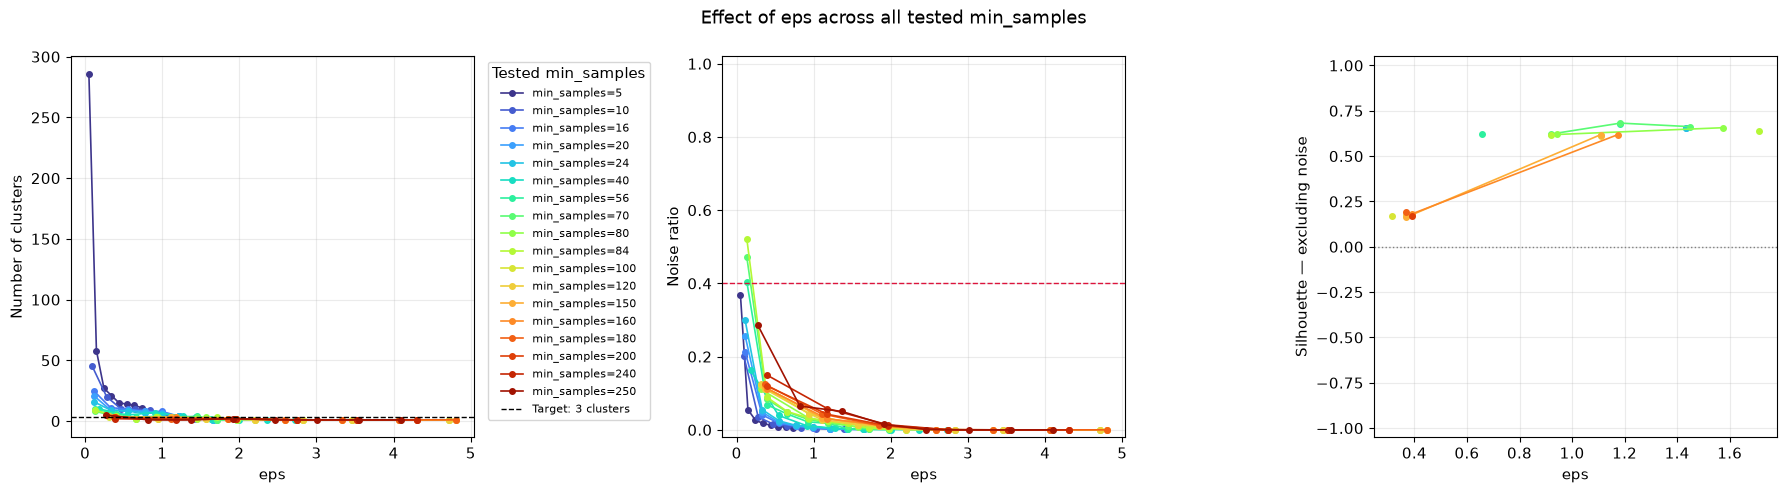

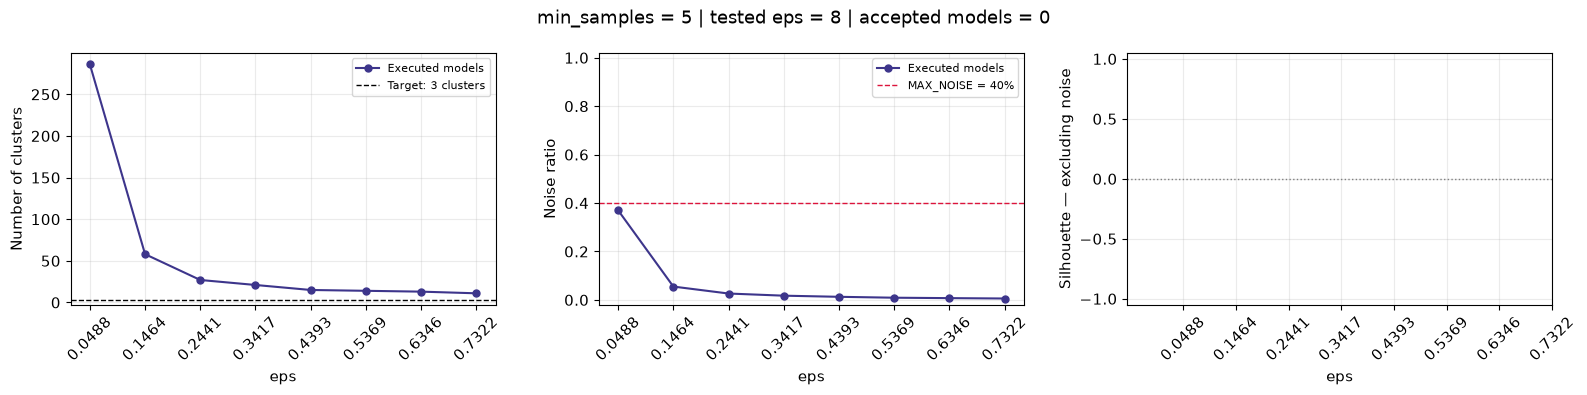

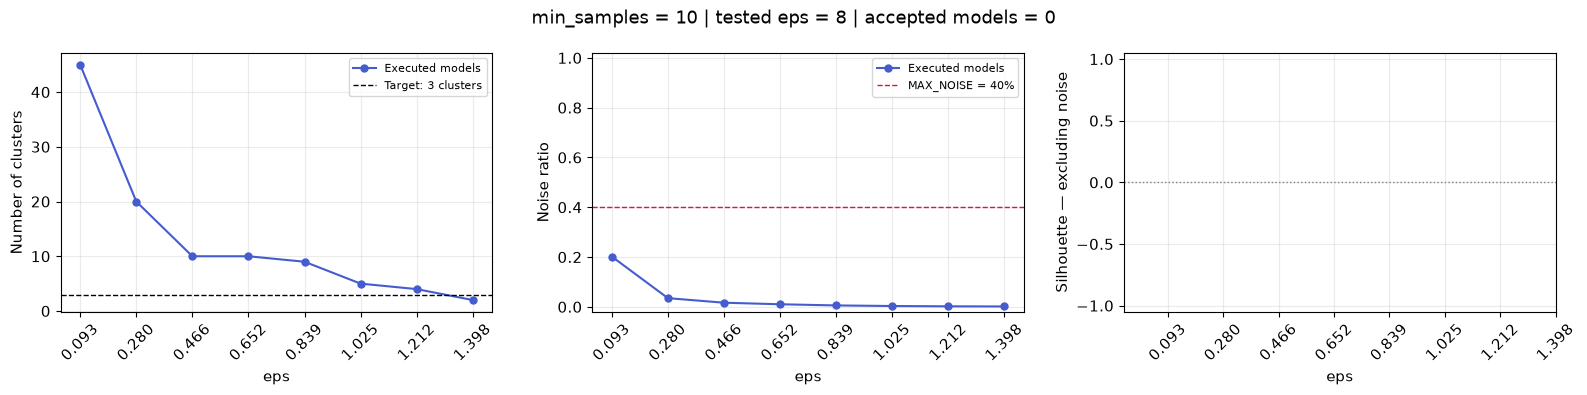

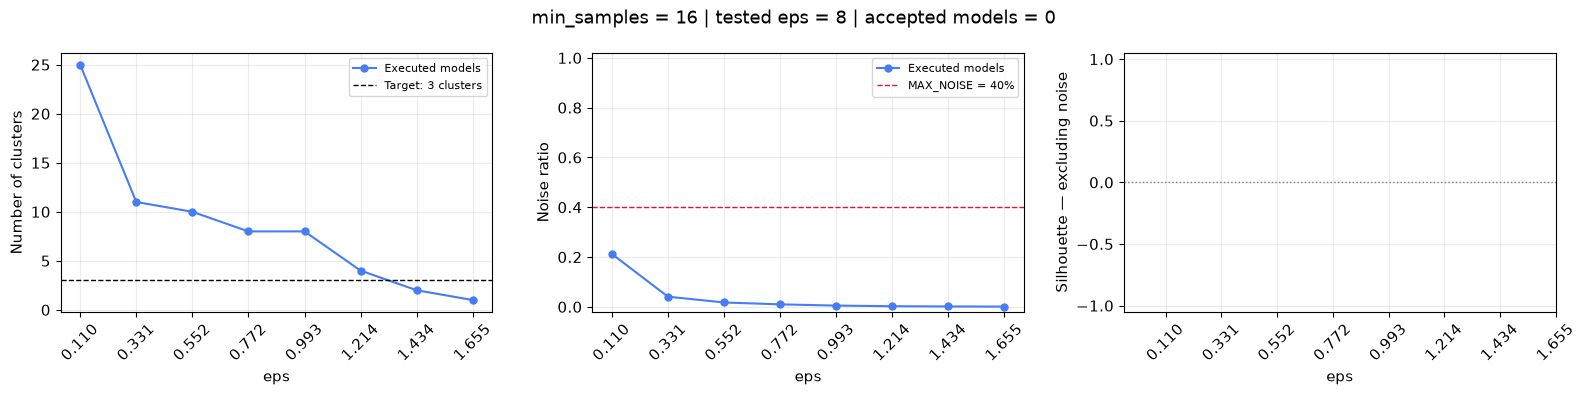

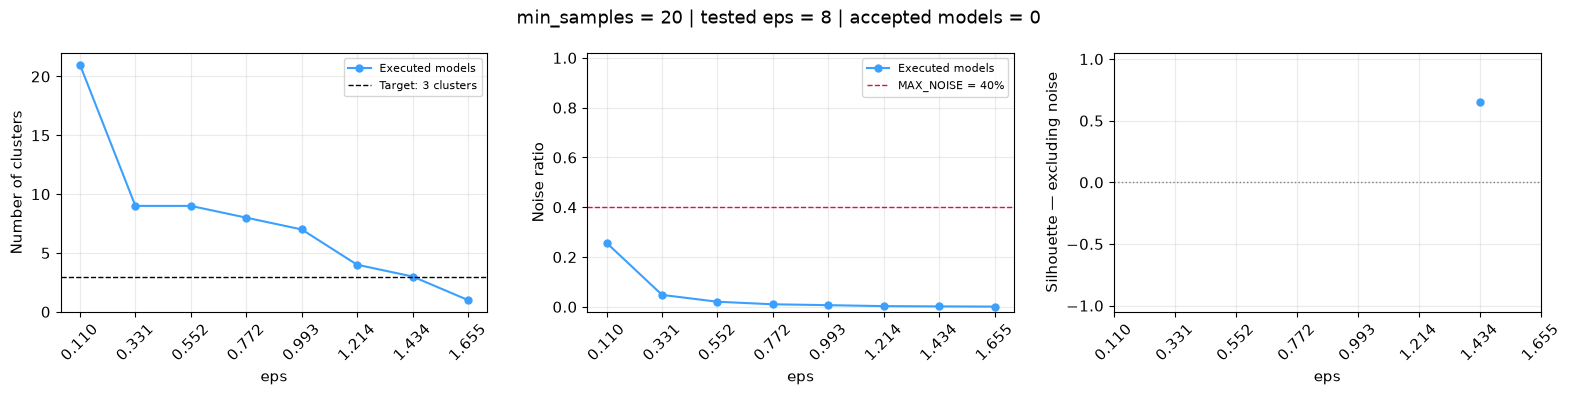

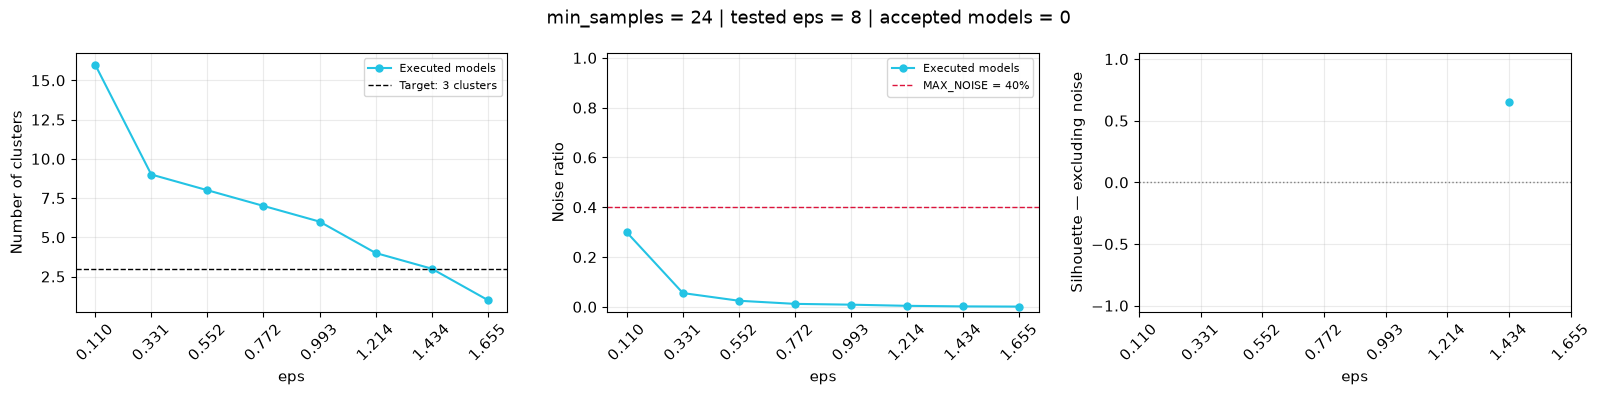

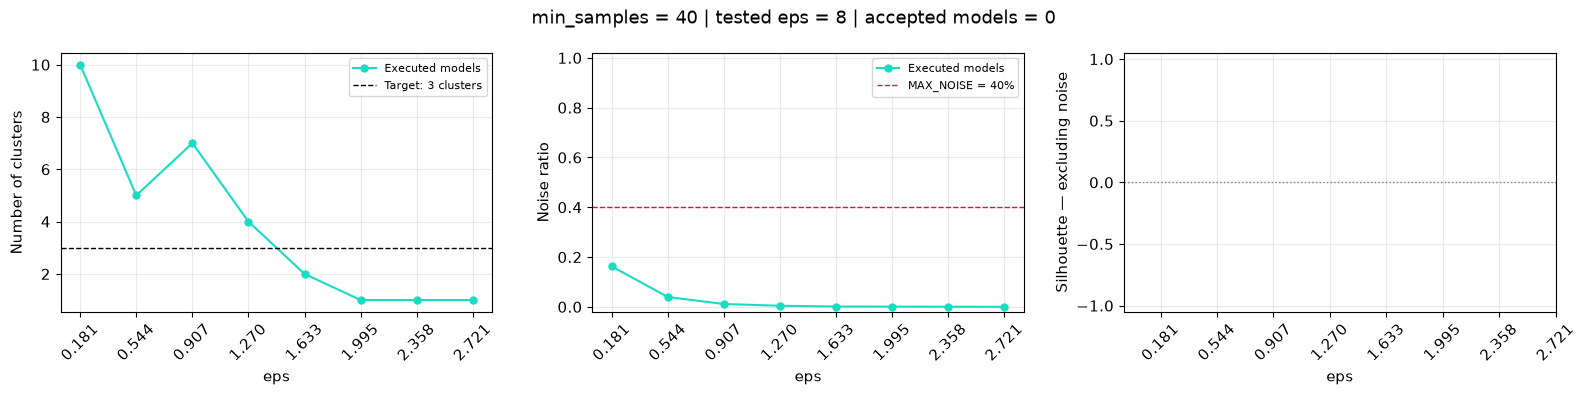

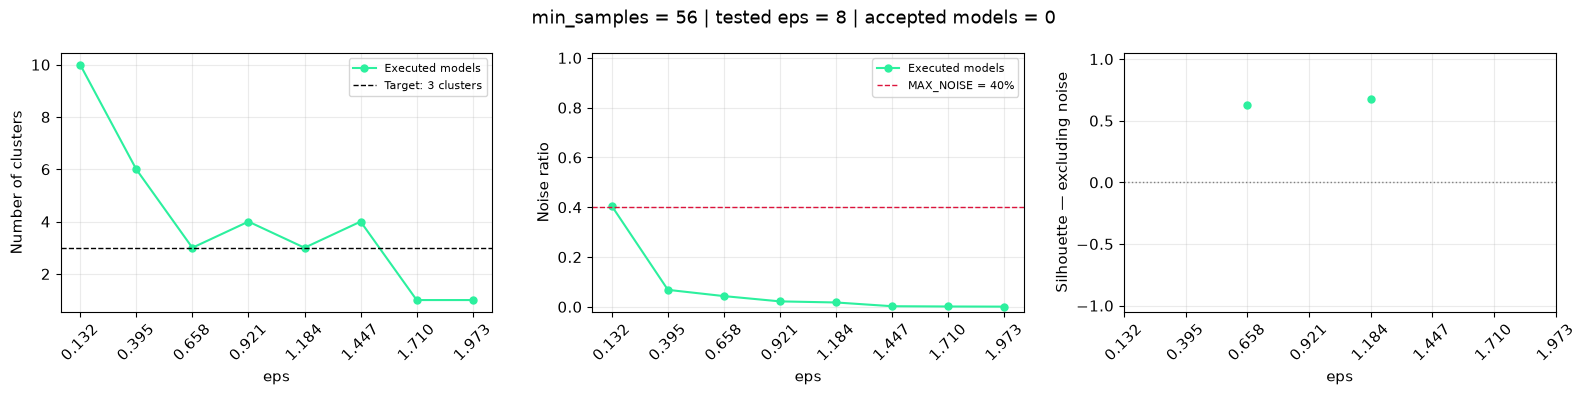

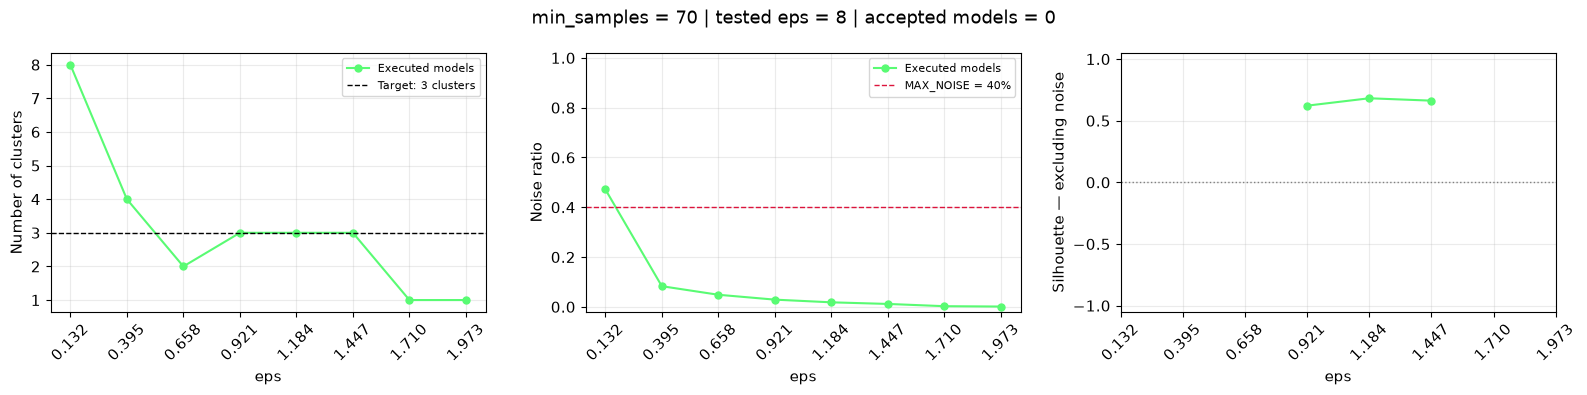

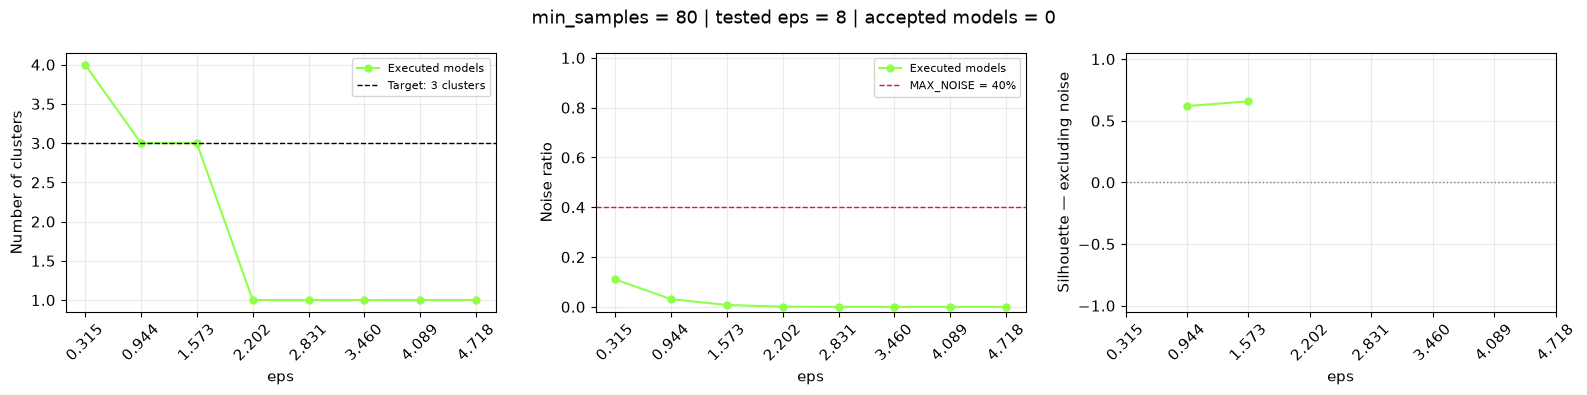

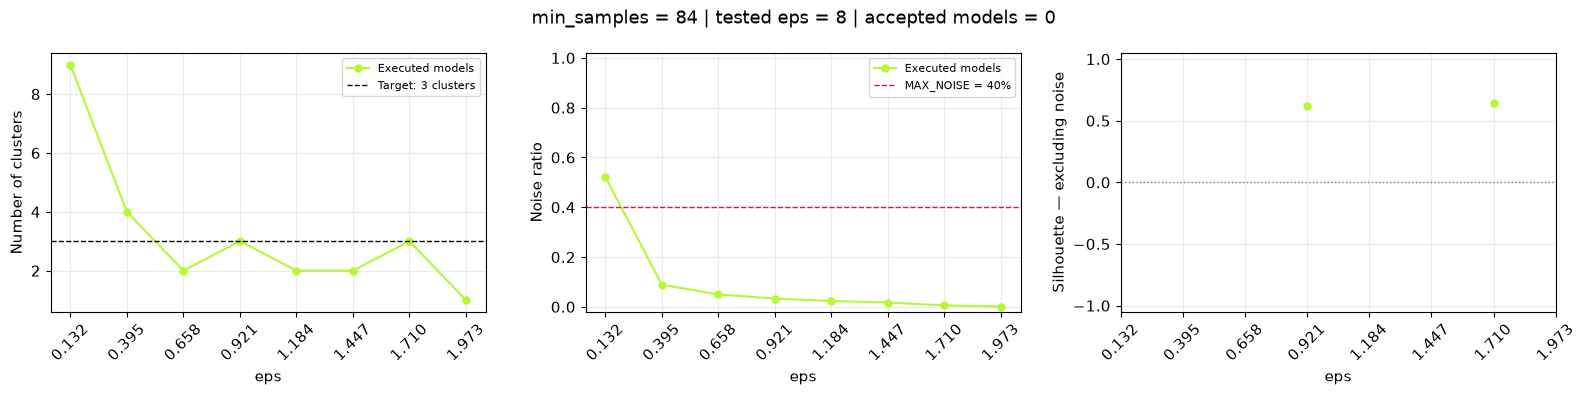

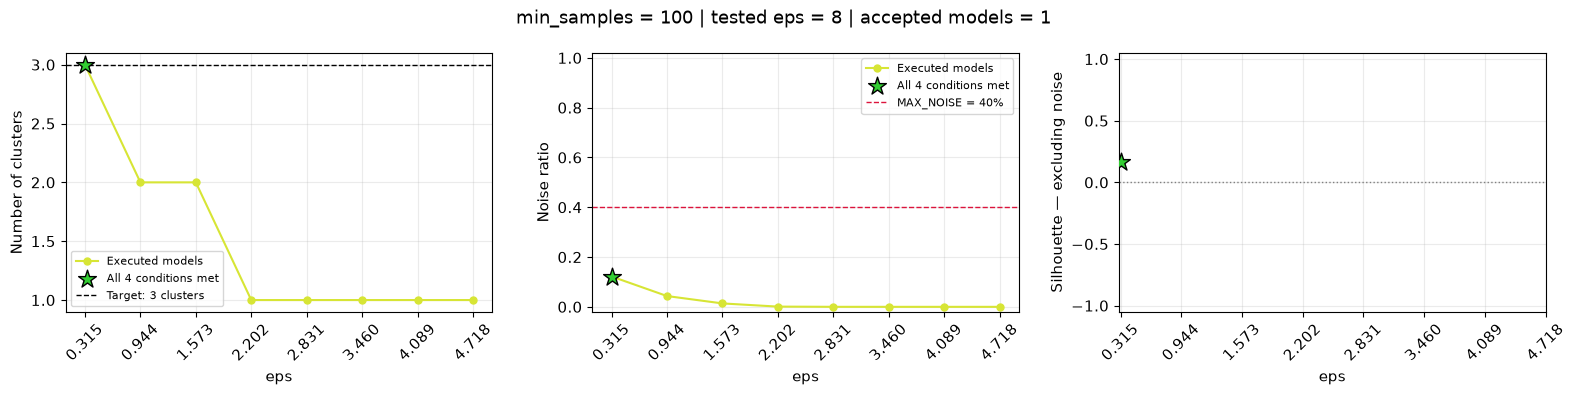

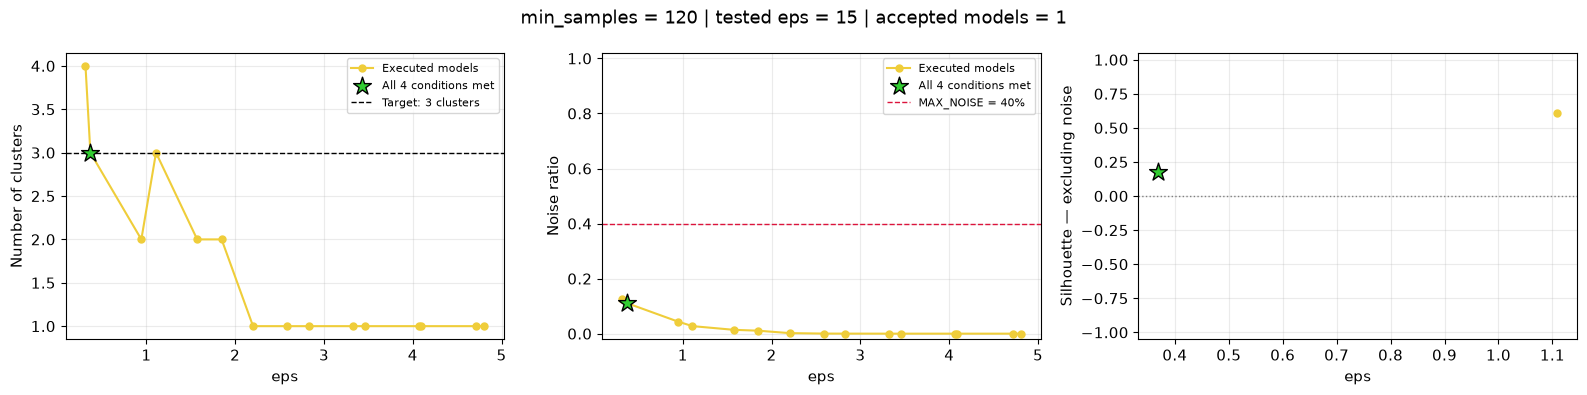

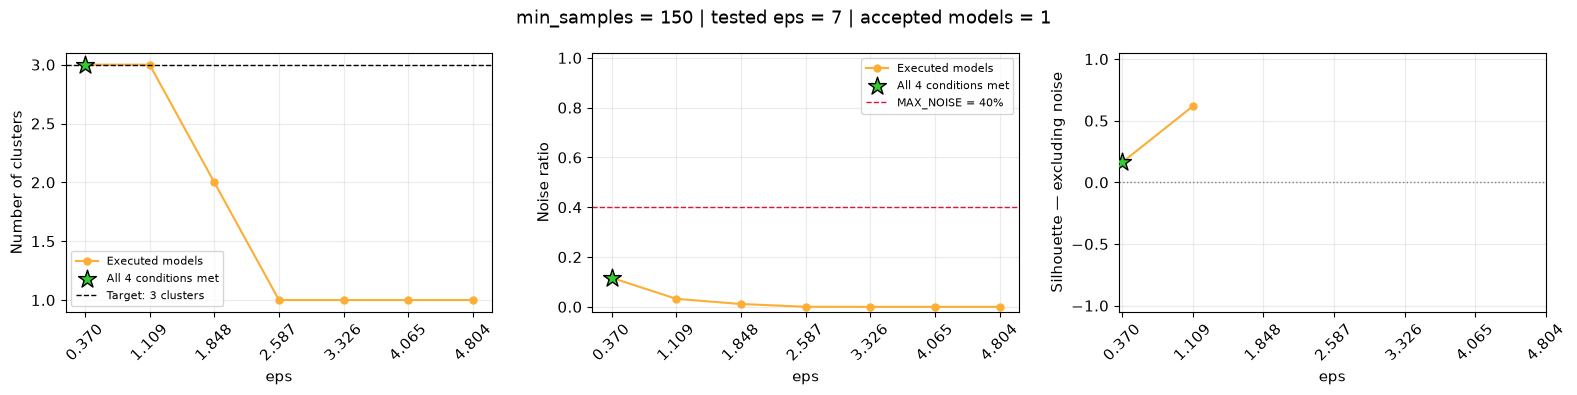

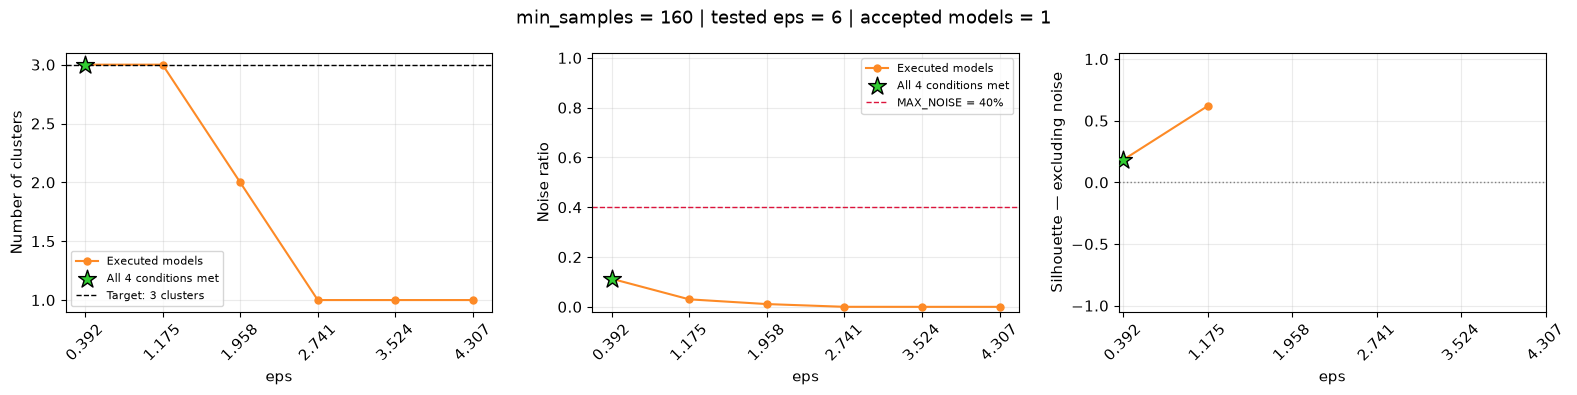

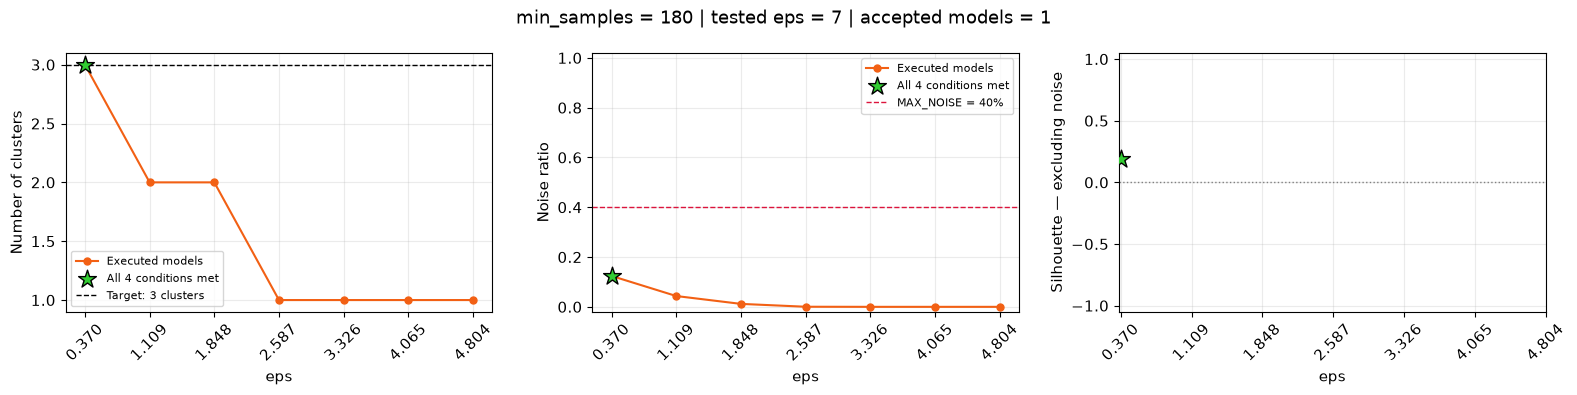

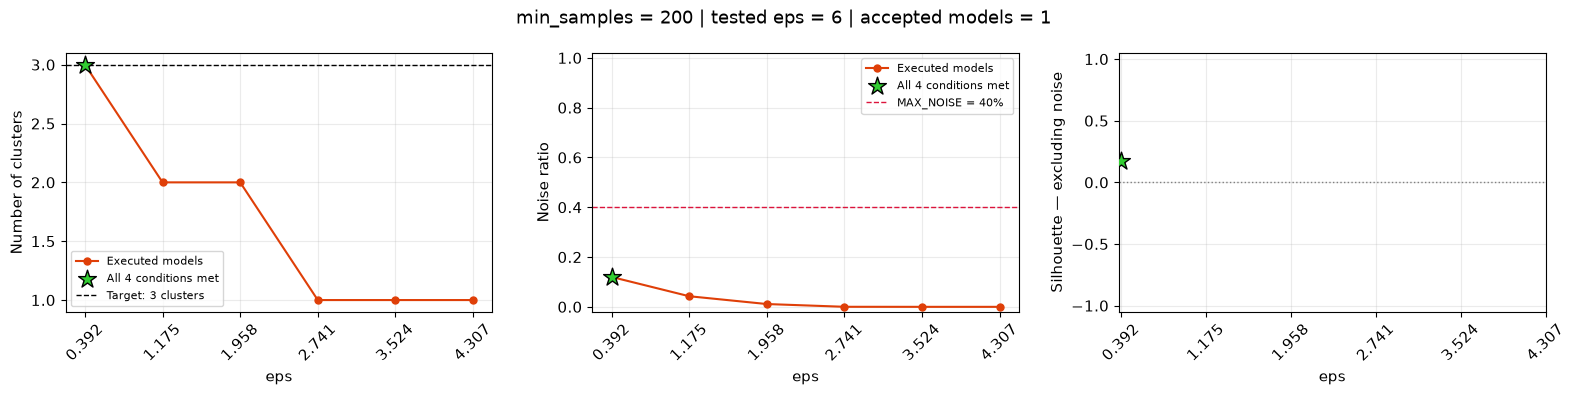

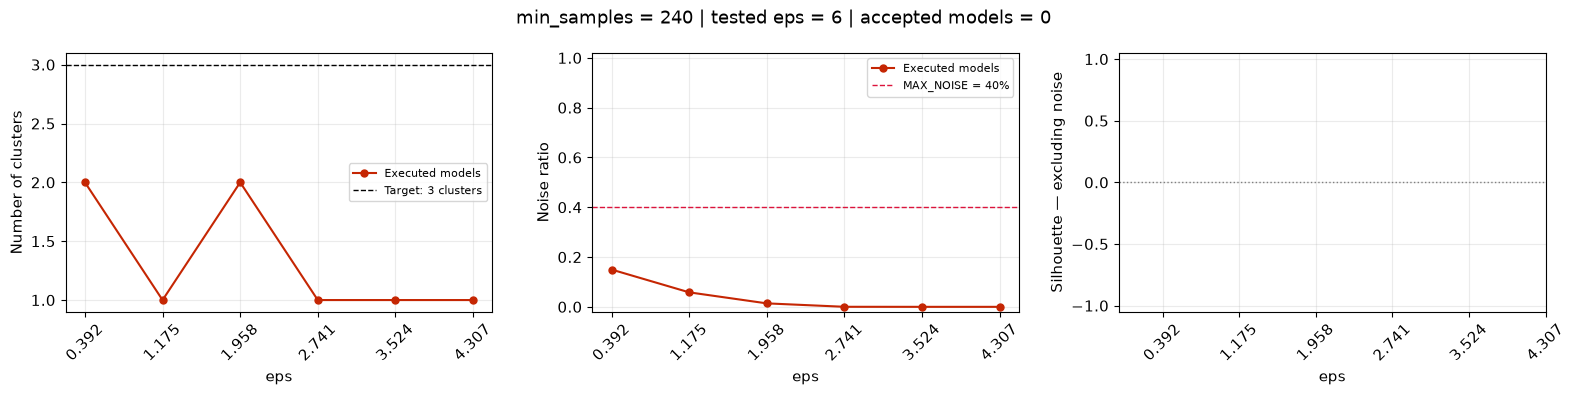

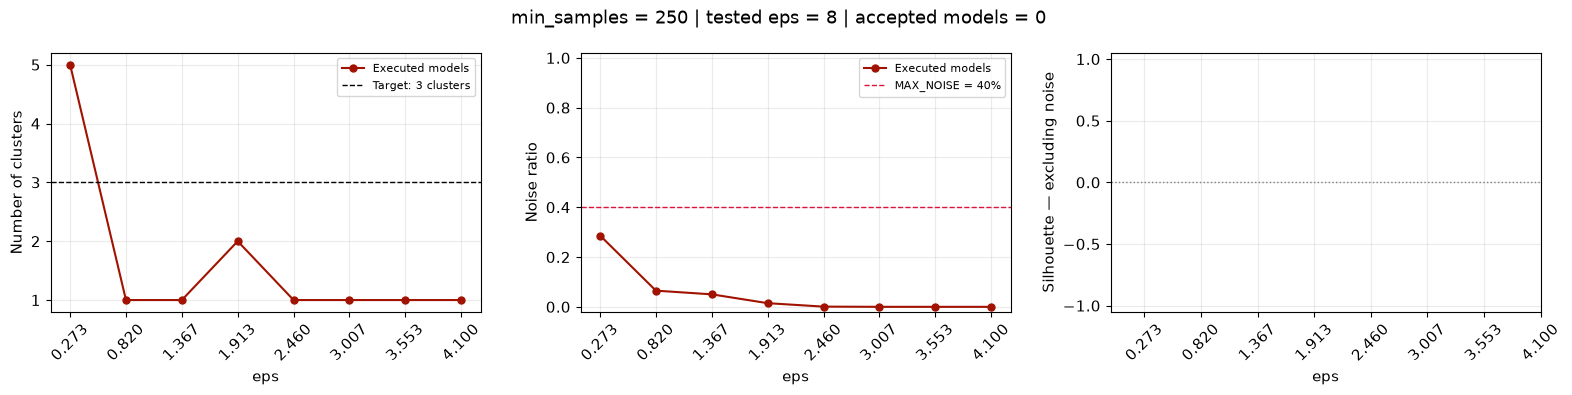

In [52]:
# تنظیمات نمایش
SHOW_OVERVIEW = True
SHOW_PER_MIN_SAMPLES = True

METRICS = [
    ("n_clusters", "Number of clusters"),
    ("noise_ratio", "Noise ratio"),
    ("silhouette", "Silhouette — excluding noise")
]

# استفاده از تمام اجراهای ثبت‌شده، بدون فیلتر کیفیت
# حتی اگر سلول ۷ پس از پایان جست‌وجو خطا داده باشد،
# نتایج اجراهای انجام‌شده در records باقی می‌مانند.
plot_results = pd.DataFrame(records).copy()

if plot_results.empty:
    raise ValueError("No executed models are available to plot.")

plot_results = plot_results.sort_values(
    ["min_samples", "eps"]
)

groups = list(plot_results.groupby("min_samples"))

colors = plt.cm.turbo(
    np.linspace(0.05, 0.95, len(groups))
)


def configure_axes(axes):
    for ax, (_, ylabel) in zip(axes, METRICS):
        ax.set_xlabel("eps")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)

    # تعداد خوشه هدف
    axes[0].axhline(
        3,
        color="black",
        linestyle="--",
        linewidth=1,
        label="Target: 3 clusters"
    )

    # آستانه نویز مجاز
    axes[1].axhline(
        MAX_NOISE,
        color="crimson",
        linestyle="--",
        linewidth=1,
        label=f"MAX_NOISE = {MAX_NOISE:.0%}"
    )
    axes[1].set_ylim(-0.02, 1.02)

    # مرجع صفر برای Silhouette
    axes[2].axhline(
        0,
        color="gray",
        linestyle=":",
        linewidth=1
    )
    axes[2].set_ylim(-1.05, 1.05)


# --------------------------------------------------
# نمودار کلی: مقایسه تمام min_samplesها
# --------------------------------------------------
if SHOW_OVERVIEW:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for (m, group), color in zip(groups, colors):
        for ax, (column, _) in zip(axes, METRICS):
            ax.plot(
                group["eps"],
                group[column],
                marker="o",
                markersize=4,
                linewidth=1.2,
                color=color,
                label=f"min_samples={m}"
            )

    configure_axes(axes)

    axes[0].legend(
        title="Tested min_samples",
        fontsize=8,
        loc="upper left",
        bbox_to_anchor=(1.02, 1)
    )

    fig.suptitle("Effect of eps across all tested min_samples")
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# نمودار مستقل برای هر min_samples
# --------------------------------------------------
if SHOW_PER_MIN_SAMPLES:
    for (m, group), color in zip(groups, colors):
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        accepted = quality_mask(group)
        valid_models = group.loc[accepted]

        for ax, (column, _) in zip(axes, METRICS):
            # تمام epsهای اجراشده برای این min_samples
            ax.plot(
                group["eps"],
                group[column],
                marker="o",
                markersize=5,
                linewidth=1.5,
                color=color,
                label="Executed models"
            )

            # مدل‌هایی که هر چهار شرط کیفیت را دارند
            if not valid_models.empty:
                ax.scatter(
                    valid_models["eps"],
                    valid_models[column],
                    marker="*",
                    s=180,
                    color="limegreen",
                    edgecolors="black",
                    zorder=5,
                    label="All 4 conditions met"
                )

            # اگر نقاط کم باشند، تمام epsها روی محور نمایش داده شوند.
            if group["eps"].nunique() <= 12:
                ax.set_xticks(group["eps"].to_numpy())
                ax.tick_params(axis="x", rotation=45)

        configure_axes(axes)

        axes[0].legend(fontsize=8)
        axes[1].legend(fontsize=8)

        fig.suptitle(
            f"min_samples = {m} | "
            f"tested eps = {group['eps'].nunique()} | "
            f"accepted models = {len(valid_models)}"
        )

        plt.tight_layout()
        plt.show()

## Cell 9:

In [53]:
def selection_score(frame, include_stability=False):
    conservative = (frame.silhouette - frame.silhouette_std).clip(-1, 1)
    score = (0.45 * (conservative + 1) / 2
             + 0.20 * (1 - frame.noise_ratio) + 0.20 * frame.balance)
    if include_stability:
        score = score + 0.15 * frame.stability
    return score

def cluster_jaccard(reference, trial):
    ref_ids = np.unique(reference[reference >= 0])
    trial_ids = np.unique(trial[trial >= 0])
    if not len(ref_ids) or not len(trial_ids):
        return 0.0
    overlaps = np.zeros((len(ref_ids), len(trial_ids)))
    for i, a in enumerate(ref_ids):
        for j, b in enumerate(trial_ids):
            left, right = reference == a, trial == b
            overlaps[i, j] = np.count_nonzero(left & right) / np.count_nonzero(left | right)
    rows, cols = linear_sum_assignment(-overlaps)
    return float(overlaps[rows, cols].sum() / max(len(ref_ids), len(trial_ids)))

def sensitivity(eps, m, reference):
    checks = []
    settings = [(eps * f, m) for f in [0.95, 1.05]]
    settings += [(eps, max(1, min(len(X), int(round(m * f))))) for f in [0.95, 1.05]]
    for trial_eps, trial_m in settings:
        trial = fit_labels(trial_eps, trial_m)
        checks.append({"eps": trial_eps, "min_samples": trial_m,
                       **evaluate(trial, compute_score=False),
                       "ARI_to_selected": adjusted_rand_score(reference, trial),
                       "cluster_jaccard": cluster_jaccard(reference, trial)})
    return pd.DataFrame(checks)

# Rebuild from canonical search records; recover even if this cell is rerun
# after X or the visible results DataFrame was changed interactively.
results = ensure_three_candidates()
three = results.loc[results.n_clusters == 3].copy()
# Use exactly the same acceptance criteria as Cell 7; no invalid fallback.
candidates = three.loc[quality_mask(three)].copy()
quality_target_met = not candidates.empty
if not quality_target_met:
    raise RuntimeError("No acceptable three-cluster model is available.")
candidates["screen_score"] = selection_score(candidates)
shortlist = candidates.sort_values("screen_score", ascending=False).head(6)
evaluated, stability_tables = [], {}
for row in shortlist.itertuples():
    candidate_labels = fit_labels(row.eps, row.min_samples)
    stats = evaluate(candidate_labels, sample_size=6000, seeds=(42, 123, 2026))
    checks = sensitivity(row.eps, row.min_samples, candidate_labels)
    stability_tables[(row.eps, row.min_samples)] = checks
    evaluated.append({"eps": row.eps, "min_samples": row.min_samples, **stats,
                      "stability": checks.cluster_jaccard.mean(),
                      "three_cluster_retention": (checks.n_clusters == 3).mean()})
    print(f"Validated eps={row.eps:.4f}, min_samples={row.min_samples}", flush=True)

ranked = pd.DataFrame(evaluated)
ranked["selection_score"] = selection_score(ranked, include_stability=True)
ranked = ranked.sort_values("selection_score", ascending=False)
best = ranked.iloc[0]
best_eps, best_min_samples = float(best.eps), int(best.min_samples)
labels = fit_labels(best_eps, best_min_samples).copy()
assert len(np.unique(labels[labels >= 0])) == 3
assert bool(quality_mask(ranked.iloc[[0]]).iloc[0])
display(ranked)
display(best.to_frame("selected"))
print("Labels and sizes (including noise -1):", np.unique(labels, return_counts=True))

baseline_labels = fit_labels(0.30, 30)
baseline_stats = evaluate(baseline_labels, sample_size=6000, seeds=(42, 123, 2026))
baseline_checks = sensitivity(0.30, 30, baseline_labels)
comparison = pd.DataFrame([
    {"model": "previous", "eps": 0.30, "min_samples": 30, **baseline_stats,
     "stability": baseline_checks.cluster_jaccard.mean(),
     "three_cluster_retention": (baseline_checks.n_clusters == 3).mean()},
    {"model": "selected", **best.to_dict()}
]).set_index("model")
comparison["selection_score"] = selection_score(comparison, include_stability=True)
display(comparison)

Validated eps=0.3916, min_samples=160
Validated eps=0.3695, min_samples=180
Validated eps=0.3695, min_samples=120
Validated eps=0.3916, min_samples=200
Validated eps=0.3695, min_samples=150
Validated eps=0.3145, min_samples=100


,eps,min_samples,n_clusters,noise_ratio,smallest_share,largest_assigned_share,balance,silhouette,silhouette_std,worst_cluster_silhouette,stability,three_cluster_retention,selection_score
2,0.369542,120,3,0.111067,0.019200,0.919079,0.298522,0.171207,0.003529,0.116046,0.991235,1.00,0.648904
4,0.369542,150,3,0.116733,0.018600,0.920673,0.294033,0.174413,0.002448,0.119970,0.990738,1.00,0.647763
0,0.391550,160,3,0.112867,0.018867,0.919441,0.297312,0.175012,0.002796,0.120160,0.902805,0.75,0.636059
1,0.369542,180,3,0.124000,0.018000,0.920928,0.292912,0.176034,0.003476,0.121849,0.920786,0.75,0.635726
5,0.314501,100,3,0.121867,0.018133,0.922183,0.289846,0.169890,0.003659,0.115357,0.929324,0.75,0.635397
3,0.391550,200,3,0.120067,0.017867,0.920600,0.293501,0.173323,0.000579,0.118714,0.895037,0.75,0.632810


,selected
eps,0.369542
min_samples,120.000000
n_clusters,3.000000
noise_ratio,0.111067
smallest_share,0.019200
largest_assigned_share,0.919079
balance,0.298522
silhouette,0.171207
silhouette_std,0.003529
worst_cluster_silhouette,0.116046


Labels and sizes (including noise -1): (array([-1,  0,  1,  2], dtype=int32), array([ 1666, 12255,   791,   288]))


,eps,min_samples,n_clusters,noise_ratio,smallest_share,largest_assigned_share,balance,silhouette,silhouette_std,worst_cluster_silhouette,stability,three_cluster_retention,selection_score
model,,,,,,,,,,,,,
previous,0.300000,30.0,7.0,0.072067,0.003267,0.886414,0.262103,0.145343,0.005565,0.071213,0.908902,0.0,0.630793
selected,0.369542,120.0,3.0,0.111067,0.019200,0.919079,0.298522,0.171207,0.003529,0.116046,0.991235,1.0,0.648904


## Cell 10:

In [54]:
checks = stability_tables[(best_eps, best_min_samples)].copy()
display(checks)
print(f"Mean cluster Jaccard: {best.stability:.3f}")
print(f"Three-cluster retention under perturbation: {best.three_cluster_retention:.0%}")

,eps,min_samples,n_clusters,noise_ratio,smallest_share,largest_assigned_share,balance,silhouette,silhouette_std,worst_cluster_silhouette,ARI_to_selected,cluster_jaccard
0,0.351065,120,3,0.116933,0.018533,0.920882,0.293443,NaN,NaN,NaN,0.982364,0.978026
1,0.388019,120,3,0.107733,0.019467,0.918410,0.300389,NaN,NaN,NaN,0.988821,0.990680
2,0.369542,114,3,0.109800,0.019267,0.919119,0.298463,NaN,NaN,NaN,0.994816,0.998358
3,0.369542,126,3,0.112533,0.019133,0.919096,0.298445,NaN,NaN,NaN,0.994211,0.997877


Mean cluster Jaccard: 0.991
Three-cluster retention under perturbation: 100%


## Cell 11:

In [55]:
clustered = clean.copy()
clustered["transformed_price_value"] = model_data["transformed_price_value"]
clustered["cluster"] = labels
members = clustered.loc[clustered["cluster"] != -1]
summary = members.groupby("cluster").agg(
    count=("price_value", "size"),
    median_price=("price_value", "median"),
    mean_price=("price_value", "mean"),
    median_easting=("utm_x", "median"),
    median_northing=("utm_y", "median")
)
summary["share_of_clean_data"] = summary["count"] / len(clustered)
centers = members.groupby("cluster")[["utm_x", "utm_y", "transformed_price_value"]].mean()
display(summary)
display(centers)
print("Noise fraction:", (labels == -1).mean())

,count,median_price,mean_price,median_easting,median_northing,share_of_clean_data
cluster,,,,,,
0,12255,22.121983,22.212284,527836.744263,3.952430e+06,0.817000
1,791,21.734867,21.726463,569914.296902,3.955496e+06,0.052733
2,288,20.946409,20.957524,473972.331894,3.982351e+06,0.019200


,utm_x,utm_y,transformed_price_value
cluster,,,
0,521531.561317,3.951691e+06,0.117583
1,571986.672039,3.955809e+06,-0.380139
2,473646.116441,3.982263e+06,-1.167915


Noise fraction: 0.11106666666666666


## Cell 12:

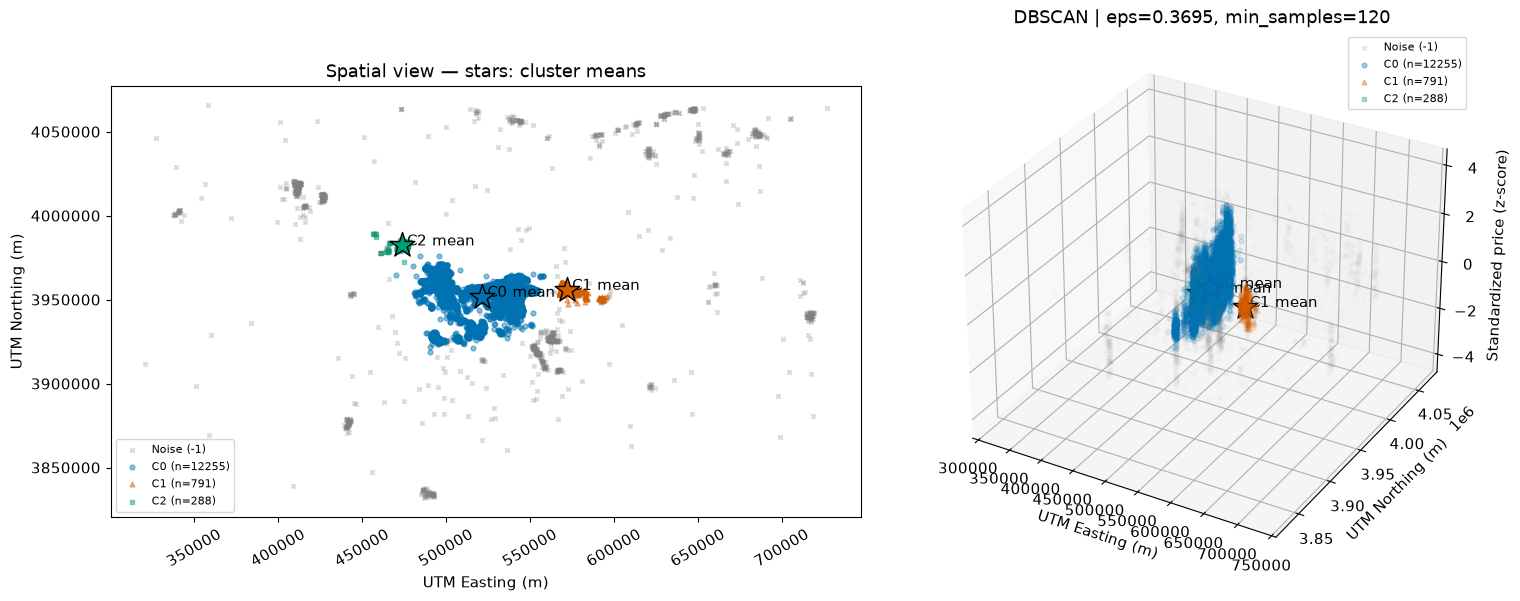

In [56]:
colors = ["#0072B2", "#D55E00", "#009E73"]
markers = ["o", "^", "s"]
fig = plt.figure(figsize=(16, 6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, projection="3d")
noise = clustered.loc[clustered["cluster"] == -1]
ax1.scatter(noise.utm_x, noise.utm_y, c="gray", marker="x", s=9, alpha=0.3, label="Noise (-1)")
ax2.scatter(noise.utm_x, noise.utm_y, noise.transformed_price_value,
            c="gray", marker="x", s=9, alpha=0.2, label="Noise (-1)")

for k, color, marker in zip(sorted(members["cluster"].unique()), colors, markers):
    group = members.loc[members["cluster"] == k]
    center = centers.loc[k]
    label = f"C{k} (n={len(group)})"
    ax1.scatter(group.utm_x, group.utm_y, c=color, marker=marker, s=12, alpha=0.45, label=label)
    ax2.scatter(group.utm_x, group.utm_y, group.transformed_price_value,
                c=color, marker=marker, s=12, alpha=0.35, label=label)
    ax1.scatter(center.utm_x, center.utm_y, c=color, marker="*", s=350, edgecolors="black", zorder=5)
    ax2.scatter(center.utm_x, center.utm_y, center.transformed_price_value,
                c=color, marker="*", s=350, edgecolors="black", depthshade=False)
    ax1.annotate(f" C{k} mean", (center.utm_x, center.utm_y))
    ax2.text(center.utm_x, center.utm_y, center.transformed_price_value, f" C{k} mean")

for ax in [ax1, ax2]:
    ax.set_xlabel("UTM Easting (m)")
    ax.set_ylabel("UTM Northing (m)")
    ax.legend(fontsize=8)
ax1.set_aspect("equal", adjustable="box")
ax1.ticklabel_format(style="plain", useOffset=False)
ax1.tick_params(axis="x", rotation=30)
ax1.set_title("Spatial view — stars: cluster means")
ax2.set_zlabel("Standardized price (z-score)")
ax2.set_title(f"DBSCAN | eps={best_eps:.4f}, min_samples={best_min_samples}")
plt.tight_layout()
plt.show()

### سلول ۱۳ ـ آیا خوشه‌ها از نظر قیمت تفاوت دارند؟

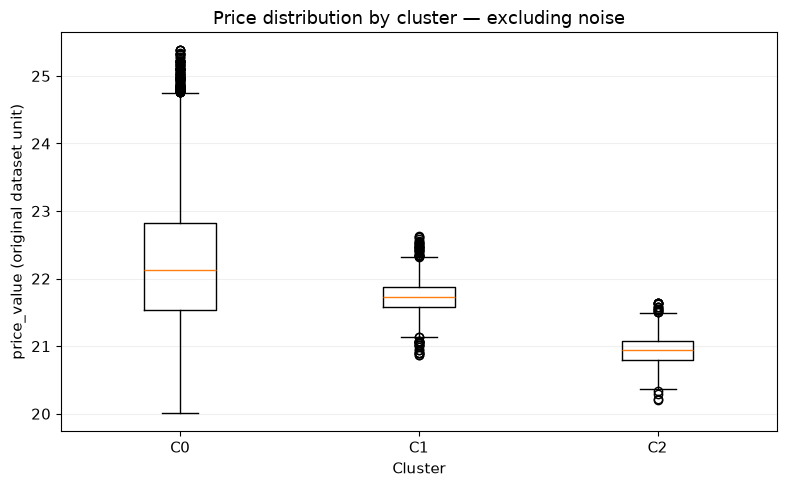

In [57]:
groups = sorted(members["cluster"].unique())
plt.figure(figsize=(8, 5))
plt.boxplot([members.loc[members["cluster"] == k, "price_value"].to_numpy() for k in groups])
plt.xticks(range(1, len(groups) + 1), [f"C{k}" for k in groups])
plt.xlabel("Cluster")
plt.ylabel("price_value (original dataset unit)")
plt.title("Price distribution by cluster — excluding noise")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()